# CS552J — Human activity classification (MSCOCO subset)


## Sections

1. **Phase A** — Data loading, cleaning, preprocessing, stratified splitting, metrics, and plottting generalization gap function.
2. **Subtask 1** — `FNN_base` vs `CNN_base`  
3. **Subtask 2** — `CNN_gen` (augmentation + regularization)  
4. **Subtask 3** — Hugging Face transfer learning, **binary** classifier (two classes)  
5. **Subtask 4** — CLIP image embeddings + small classifier  
6. **Subtask 5** — CLIP cosine similarity / text–image features  
7. **Summary** — Results table; report checklist  

Install dependencies once: `pip install -r requirements.txt`

**Phase A**: Library imports, Global constants — reproducibility, paths, hyperparameters, data loading, cleaning, preprocessing, and stratified splitting (train/val/test - 70/15/15)

In [54]:
import os
import random
import warnings
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# Install pytorch-grad-cam if not already installed
try:
    import pytorch_grad_cam
except ImportError:
    !pip install pytorch-grad-cam

# ---------------------------------------------------------------------------
# Global constants — reproducibility, paths, and hyperparameters
# ---------------------------------------------------------------------------

# --- Reproducibility (set global seed + pip freeze) ---
# Setting a global seed ensures that random operations are consistent across runs,
# which is crucial for reproducible research and debugging.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Resize every image to a square so batch tensors are rectangular and FNN input
# dimension is fixed. 224 is a common ImageNet-style size.
IMG_SIZE = 224

# ImageNet normalization statistics (RGB). Using them for a non-ImageNet task is a
# convention that stabilizes optimization.
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

# Batch size: balances gradient noise vs memory. Number of samples per batch during training. 32 is small enough for CPU laptops while still giving stable batch statistics for BN.
BATCH_SIZE = 32

# Adam learning rate: 1e-3 is a standard default for small vision models from scratch.
LEARNING_RATE = 1e-3

# Maximum number of training epochs; early stopping (below) usually finishes sooner.
EPOCHS = 60

# Early stopping patience: number of epochs without val_accuracy improvement before stop.
EARLY_STOPPING_PATIENCE = 8

# Optimizes data pipeline performance for TensorFlow
AUTOTUNE = tf.data.AUTOTUNE

# Load and clean dataframe to prepare the dataset
# This CSV contains metadata about the images, including file names and labels.
df = pd.read_csv("cs552j_A1_dataset_image_id_url.csv")

# Number of unique classes in the dataset
NUM_CLASSES = df["label"].nunique()

def load_and_clean_dataframe(csv_path: str) -> pd.DataFrame:
    """
    Read the image catalogue and clean the DataFrame by removing potential unnamed index columns.

    Parameters
    ----------
    csv_path
        Path to cs552j_A1_dataset_image_id_url.csv.

    Returns
    -------
    pd.DataFrame
        Cleaned table with at least `file_name`, `coco_url`, and `label`.
    """
    df = pd.read_csv(csv_path)
    # Some exports include an unnamed first column of row indices; remove if present.
    if str(df.columns[0]).startswith("Unnamed") or df.columns[0] == "":
        df = df.drop(columns=[df.columns[0]])
        print(df["label"].value_counts())
        print("Rows:", len(df))
    return df

load_and_clean_dataframe("cs552j_A1_dataset_image_id_url.csv")

def build_label_mappings(df: pd.DataFrame) -> tuple[dict[str, int], dict[int, str], list[str]]:
    """
    Create fixed integer IDs for each activity label (sorted for stable ordering).

    Parameters
    ----------
    df
        Dataframe containing a string `label` column.

    Returns
    -------
    label2id
        Maps class name → integer used as sparse label in loss/metrics.
    id2label
        Inverse map for human-readable reports and plot tick labels.
    class_names
        Sorted list of class names; index i matches model logit i.
    """
    # Sorting alphabetically makes class order deterministic across students/machines.
    class_names = sorted(df["label"].unique().tolist())
    label2id = {name: i for i, name in enumerate(class_names)}
    id2label = {i: name for name, i in label2id.items()}
    return label2id, id2label, class_names

LABEL2ID, ID2LABEL, class_names = build_label_mappings(df)
print("LABEL2ID:", LABEL2ID)
print("Classes:", class_names)

# Folder where you want to save the image. This folder will store the downloaded COCO images.
save_folder = "a1_images"
os.makedirs(save_folder, exist_ok=True) # Create the directory if it doesn't already exist.

def download_image(image_url, save_folder, skip_existing=True):
    """Downloads an image from a given URL and saves it to a specified folder.

    Args:
        image_url (str): The URL of the image to download.
        save_folder (str): The directory where the image will be saved.
        skip_existing (bool): If True, skips download if the file already exists.

    Returns:
        str: The path to the saved image file.
    """
    # Extract filename from URL and construct the full save path
    image_name = os.path.join(save_folder, image_url.split("/")[-1])

    # Skip download if the file already exists and skip_existing is True
    if skip_existing and os.path.isfile(image_name):
        return image_name

    # Send an HTTP GET request to download the image, with a 60-second timeout
    response = requests.get(image_url, timeout=60)

    # Check if the download was successful (status code 200)
    if response.status_code == 200:
        # Write the image content to a file in binary mode
        with open(image_name, "wb") as file:
            file.write(response.content)
        print(f"Saved: {image_name}")
    else:
        # Print an error message if the download failed
        print(f"Failed: {image_url}")
    return image_name

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
label
walking_running    98
sitting            95
standing           92
Name: count, dtype: int64
Rows: 285
LABEL2ID: {'sitting': 0, 'standing': 1, 'walking_running': 2}
Classes: ['sitting', 'standing', 'walking_running']


In [2]:
# Run once to download all images listed in the DataFrame.
# It skips files that are already present in the 'save_folder' to avoid redundant downloads.
for url in df.coco_url.values:
    download_image(url, save_folder, skip_existing=True)

Saved: a1_images/000000252219.jpg
Saved: a1_images/000000386912.jpg
Saved: a1_images/000000308394.jpg
Saved: a1_images/000000456496.jpg
Saved: a1_images/000000185250.jpg
Saved: a1_images/000000356427.jpg
Saved: a1_images/000000266409.jpg
Saved: a1_images/000000515579.jpg
Saved: a1_images/000000551215.jpg
Saved: a1_images/000000057597.jpg
Saved: a1_images/000000399462.jpg
Saved: a1_images/000000494869.jpg
Saved: a1_images/000000329219.jpg
Saved: a1_images/000000214720.jpg
Saved: a1_images/000000459153.jpg
Saved: a1_images/000000295713.jpg
Saved: a1_images/000000273132.jpg
Saved: a1_images/000000476415.jpg
Saved: a1_images/000000292082.jpg
Saved: a1_images/000000122046.jpg
Saved: a1_images/000000352684.jpg
Saved: a1_images/000000512836.jpg
Saved: a1_images/000000177015.jpg
Saved: a1_images/000000288042.jpg
Saved: a1_images/000000347265.jpg
Saved: a1_images/000000264535.jpg
Saved: a1_images/000000337055.jpg
Saved: a1_images/000000100624.jpg
Saved: a1_images/000000202228.jpg
Saved: a1_imag

In [3]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import os
import torch

# Folder where images are saved, created in a previous cell
save_folder = "a1_images"
os.makedirs(save_folder, exist_ok=True)

def is_valid_image(path: str) -> bool:
    """Return True only if PIL can open and verify the file bytes.

    This catches corrupted files early so training does not fail mid-epoch.

    Args:
        path (str): The file path to the image.

    Returns:
        bool: True if the image is valid and readable, False otherwise.
    """
    try:
        with Image.open(path) as img:
            # verify() checks file integrity without fully decoding pixels.
            img.verify()
        return True
    except (Image.UnidentifiedImageError, OSError, FileNotFoundError): # Handles corrupted, unidentifiable, or missing image files
        return False

def build_path_label_arrays(frame):
    """Builds arrays of image file paths and their corresponding labels.

    It also performs checks for missing files and corrupted images.

    Args:
        frame (pd.DataFrame): DataFrame containing 'file_name' and 'label' columns.

    Returns:
        tuple: A tuple containing two NumPy arrays: (image_paths, labels).
    """
    paths, labels = [], []
    missing = [] # Stores paths of files that could not be found
    bad_file = [] # Stores paths of files that are corrupted or unreadable

    for _, row in frame.iterrows():
        fn = row["file_name"]
        p = os.path.join(save_folder, fn)
        # Check if the file exists on disk
        if not os.path.isfile(p):
            missing.append(p)
            continue # Skip to the next image
        # Check if the image file is valid and readable
        if not is_valid_image(p):
            # Skip corrupted images to keep the training pipeline robust.
            bad_file.append(p)
            continue # Skip to the next image
        paths.append(p)
        labels.append(LABEL2ID[row["label"]]) # Convert string label to integer ID

    if missing:
        print(f"Warning: {len(missing)} files missing (run download cell).")
    if bad_file:
        print(f"Warning: {len(bad_file)} corrupted files skipped.") # Message for corrupted files

    return np.array(paths), np.array(labels)


# Define the data splitting function
def perform_data_split(df, SEED):
    """Splits the dataset into training, validation, and test sets.

    The split is stratified to maintain the proportion of classes in each set.

    Args:
        df (pd.DataFrame): The input DataFrame containing image metadata.
        SEED (int): Random seed for reproducibility of the splits.

    Returns:
        tuple: (train_paths, train_y, val_paths, val_y, test_paths, test_y)
               where _paths are image file paths and _y are corresponding labels.
    """
    # Build all valid image paths and their labels from the DataFrame
    paths_all, y_all = build_path_label_arrays(df)
    # Ensure that some images were successfully found before splitting
    assert len(paths_all) > 0, "No images found. Run the download cell above."

    idx = np.arange(len(paths_all)) # Create an array of indices for all images

    # First split: 70% for training, 30% for a temporary set (validation + test)
    # Stratify ensures class distribution is preserved
    idx_train, idx_temp, y_train_split, y_temp_split = train_test_split(
        idx, y_all, test_size=0.3, random_state=SEED, stratify=y_all
    )

    # Second split: Divide the 30% temporary set into 15% validation and 15% test
    # Stratify again to preserve class distribution in val/test sets
    idx_val, idx_test, y_val_split, y_test_split = train_test_split(
        idx_temp, y_temp_split, test_size=0.50, random_state=SEED, stratify=y_temp_split
    )

    # Use the generated indices to get the actual paths and labels for each split
    train_paths, train_y = paths_all[idx_train], y_all[idx_train]
    val_paths, val_y = paths_all[idx_val], y_all[idx_val]
    test_paths, test_y = paths_all[idx_test], y_all[idx_test]

    return train_paths, train_y, val_paths, val_y, test_paths, test_y

# Split the dataset by calling the data splitting function
train_paths, train_y, val_paths, val_y, test_paths, test_y = perform_data_split(df, SEED)

# Print the counts of images in each split for verification
print("Train:", len(train_paths), "Val:", len(val_paths), "Test:", len(test_paths))


# tf.data map step: load bytes from disk, decode JPEG, resize, scale, normalize.
def preprocess(image_path, label):
    """Performs preprocessing steps for a single image for TensorFlow/Keras models.

    Args:
        image_path (tf.Tensor): The path to the image file.
        label (tf.Tensor): The corresponding label.

    Returns:
        tuple: A tuple containing the processed image tensor and its label.
    """
    image = tf.io.read_file(image_path) # Read the image file from disk
    image = tf.image.decode_jpeg(image, channels=3) # Decode JPEG image to a 3-channel (RGB) tensor
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)) # Resize image to the target IMG_SIZE
    image = tf.cast(image, tf.float32) / 255.0  # Normalize pixel values from [0, 255] to [0, 1]
    label = tf.cast(label, tf.int32)
    image = (image - IMAGENET_MEAN) / IMAGENET_STD
    return image, label

# Create tf.data.Dataset objects from NumPy arrays for Keras models
# These datasets are optimized for performance with prefetching and parallel mapping.
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_y)) # Create dataset from training paths and labels
    .map(preprocess, num_parallel_calls=AUTOTUNE) # Apply preprocessing function in parallel
    .shuffle(2000, seed=42) # Shuffle the training data to ensure randomness
    .batch(BATCH_SIZE) # Group elements into batches
    .prefetch(AUTOTUNE) # Prefetch batches to improve data loading pipeline performance
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_y)) # Create dataset from validation paths and labels
    .map(preprocess, num_parallel_calls=AUTOTUNE) # Apply preprocessing
    .batch(BATCH_SIZE) # Group elements into batches
    .prefetch(AUTOTUNE) # Prefetch batches
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_y)) # Create dataset from test paths and labels
    .map(preprocess, num_parallel_calls=AUTOTUNE) # Apply preprocessing
    .batch(BATCH_SIZE) # Group elements into batches
    .prefetch(AUTOTUNE) # Prefetch batches
)
# Print the number of images in each dataset (actual and approximate due to batching)
print(f"Training   : {len(train_paths)} images")
print(f"Validation : {len(val_paths)} (actual count), {tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE} (due to batching) images (approx)")
print(f"Test       : {len(test_paths)} (actual count), {tf.data.experimental.cardinality(test_ds).numpy() * BATCH_SIZE} (due to batching) images (approx)")


Train: 199 Val: 43 Test: 43
Training   : 199 images
Validation : 43 (actual count), 64 (due to batching) images (approx)
Test       : 43 (actual count), 64 (due to batching) images (approx)


In [4]:
# Plotting Generalization Gap
all_histories = {} # Dictionary to store training histories of all models

def plot_curves(history, title):
    """Plots training and validation loss, accuracy, and generalization gap over epochs.

    Args:
        history (keras.callbacks.History): The history object returned by model.fit().
        title (str): The title for the combined plot.
    """
    # Extract training and validation accuracy from the history object
    train_acc = np.array(history.history['accuracy'])
    val_acc   = np.array(history.history['val_accuracy'])

    # Calculate the generalization gap (difference between train and val accuracy)
    gap       = train_acc - val_acc
    epochs    = range(1, len(train_acc) + 1) # Epoch numbers for x-axis

    fig, axes = plt.subplots(1, 3, figsize=(15, 4)) # Create a figure with 3 subplots
    fig.suptitle(title, fontsize=13) # Set a main title for the figure

    # Subplot 1: Loss curves
    axes[0].plot(epochs, history.history['loss'],     label='Train')
    axes[0].plot(epochs, history.history['val_loss'], label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Subplot 2: Accuracy curves and generalization gap area
    axes[1].plot(epochs, train_acc, label='Train')
    axes[1].plot(epochs, val_acc,   label='Val')
    # Fill the area between train and val accuracy to visually represent the gap
    axes[1].fill_between(epochs, train_acc, val_acc, alpha=0.15, color='red', label='Gap')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylim([0, 1.05]) # Set y-axis limits for accuracy between 0 and 1
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Subplot 3: Bar chart of generalization gap per epoch
    # Color bars based on the magnitude of the gap
    axes[2].bar(epochs, gap,
                color=['green' if g < 0.05 else 'orange' if g < 0.15 else 'red' for g in gap])
    axes[2].axhline(0, color='black', linewidth=0.8) # Horizontal line at zero gap
    axes[2].set_title('Generalization Gap per Epoch')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylim([-0.05, 0.7]) # Set y-axis limits for the gap
    axes[2].grid(alpha=0.3)

    plt.tight_layout() # Adjust layout to prevent overlapping elements
    plt.show() # Display the plot

    # Print final and best metrics for quick summary
    print(f"  Final train acc : {train_acc[-1]:.3f}")
    print(f"  Best val acc    : {val_acc.max():.3f}")
    print(f"  Final gap       : {gap[-1]:+.3f}")

## Subtask 1 — `FNN_base` vs `CNN_base`

- **FNN_base:** fully-connected network on flattened normalized pixels.  
- **CNN_base:** small convolutional network trained from scratch.  

Same train/val/test split and evaluation protocol.

1- FNN_base: building, training, and evaluating the FNN baseline model (+ plotting the generalization gap)

Model: "FNN_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,072,387 (294.01 MB)

 Trainable params: 77,072,387 (294.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.3166 - loss: 224.3372 - val_accuracy: 0.3953 - val_loss: 198.2813
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5628 - loss: 128.8078 - val_accuracy: 0.3256 - val_loss: 166.2744
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6332 - loss: 89.9264 - val_accuracy: 0.4186 - val_loss: 152.4306
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7688 - loss: 28.9424 - val_accuracy: 0.4419 - val_loss: 117.9080
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8593 - loss: 15.1495 - val_accuracy: 0.3721 - val_loss: 108.6656
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8794 - loss: 9.9282 - val_accuracy: 0.4651 - val_loss: 89.8931
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9548 - loss: 3.5344 - val_accuracy: 0.3953 - val_loss: 102.7402
Epoch 8/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9447 - loss: 1.7733 - val_accuracy: 0.4186 - val_l

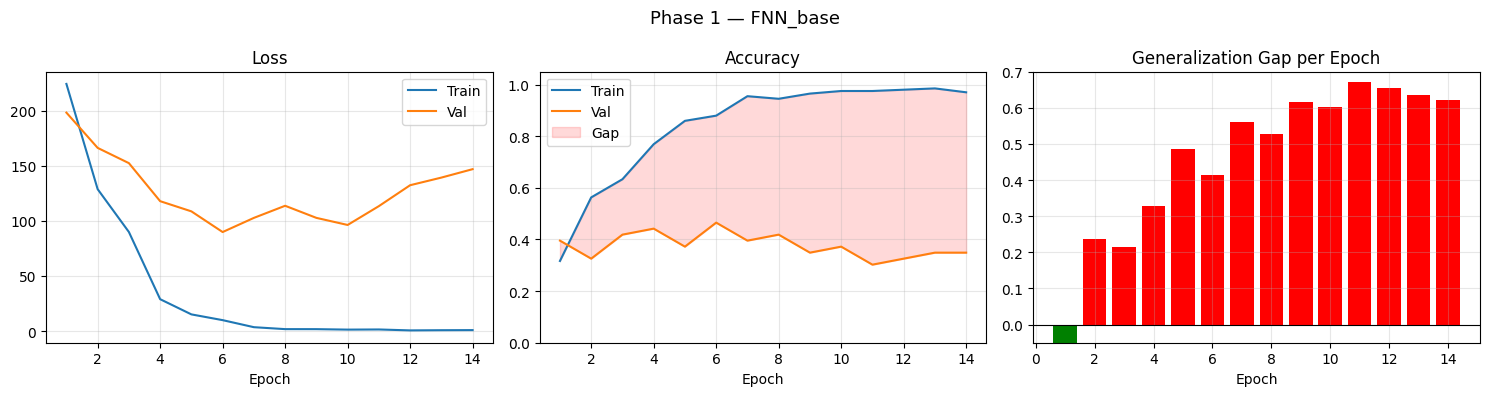

  Final train acc : 0.970
  Best val acc    : 0.465
  Final gap       : +0.621


In [5]:
FNN_base = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), # Define input shape for images
    layers.Flatten(), # Flatten the 2D image data into a 1D vector
    layers.Dense(512, activation='relu'), # First dense layer with 512 units and ReLU activation
    layers.Dense(NUM_CLASSES, activation='softmax') # Output layer with NUM_CLASSES units and softmax for multi-class classification
], name='FNN_base')

FNN_base.compile(
    optimizer='adam', # Use Adam optimizer for training
    loss='sparse_categorical_crossentropy', # Use sparse categorical crossentropy for integer labels
    metrics=['accuracy'] # Monitor accuracy during training
)

FNN_base.summary() # Print a summary of the model architecture

# Define the EarlyStopping callback
early_stopping_fnn = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history_FNN_base = FNN_base.fit(
    train_ds, # Training dataset
    epochs=EPOCHS, # Number of training epochs
    validation_data=val_ds, # Validation dataset to evaluate performance after each epoch
    callbacks=[early_stopping_fnn] # Pass the EarlyStopping callback
)

all_histories['FNN_base'] = history_FNN_base # Store the training history in a dictionary
plot_curves(history_FNN_base, 'Phase 1 — FNN_base') # Plot learning curves for FNN_base

2/2 - 0s - 196ms/step - accuracy: 0.4651 - loss: 89.8931
Accuracy on validation dataset: 0.4651162922382355
Correct predicted classes: 20
Incorrect predicted classes: 23


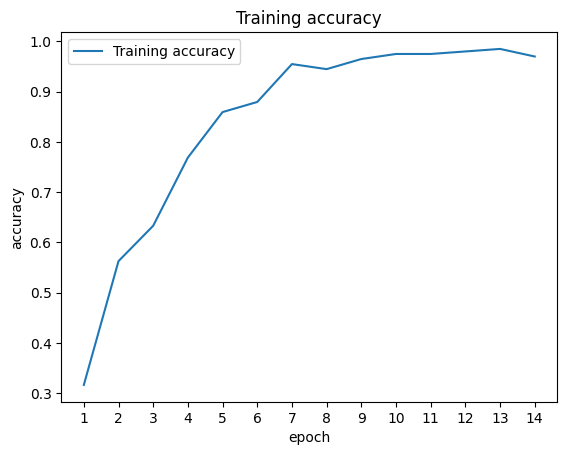

In [6]:
#-----------------------------------------------------------
#   This block is for evaluating FNN_base model
#-----------------------------------------------------------

# accuracy values are stored in the dictionary `History.history`
# the dictonary key to access these accuracy values are:
# "acc" in tensorflow versions <2
# "accuracy" in later versions

# check the current version of TensorFlow to determine the correct accuracy key
if int(tf.__version__.split('.')[0]) > 1:
    acc_key = 'accuracy'
else:
    acc_key = 'acc'

#-----------------------------------------------------------
# Retrieve a list of list results on training and validation data
# sets for each training epoch from the FNN baseline's history
#-----------------------------------------------------------
acc      = history_FNN_base.history[acc_key] # Get training accuracy values
loss     = history_FNN_base.history['loss'] # Get training loss values
epochs   = range(1,len(acc)+1) # Generate epoch numbers for x-axis
#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc,  label='Training accuracy') # Plot training accuracy over epochs
plt.title('Training accuracy') # Set plot title
plt.xticks(epochs) # Set x-axis ticks to match epoch numbers
plt.xlabel('epoch') # Set x-axis label
plt.ylabel('accuracy') # Set y-axis label
plt.legend(); # Display legend

# Validate on the validation split (reserve test set for final comparison only)
val_loss, val_accuracy = FNN_base.evaluate(val_ds, verbose=2)
print('Accuracy on validation dataset:', val_accuracy)

# Predictions on validation data
predicted_classes = np.argmax(FNN_base.predict(val_ds, verbose=0), axis=-1)
y_true = val_y

# to get the total correct and incorrect prediction from the predict class
correct = np.nonzero(predicted_classes == y_true)[0]
incorrect = np.nonzero(predicted_classes != y_true)[0]

print("Correct predicted classes:", correct.shape[0])
print("Incorrect predicted classes:", incorrect.shape[0])

2- CNN_base: building, training, and evaluating the CNN baseline model (+ plotting the generalization gap)

Model: "CNN_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,603,651 (13.75 MB)

 Trainable params: 3,602,691 (13.74 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.3015 - loss: 14.7253 - val_accuracy: 0.3256 - val_loss: 3.6860
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.3719 - loss: 3.5891 - val_accuracy: 0.3488 - val_loss: 4.9010
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.4975 - loss: 1.2884 - val_accuracy: 0.3256 - val_loss: 5.4571
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.4573 - loss: 1.1896 - val_accuracy: 0.3721 - val_loss: 2.2080
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.4623 - loss: 0.9885 - val_accuracy: 0.3023 - val_loss: 1.7047
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.5276 - loss: 0.9133 - val_accuracy: 0.3023 - val_loss: 1.5181
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.5528 - loss: 0.8767 - val_accuracy: 0.2791 - val_loss: 1.3754
Epoch 8/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.6080 - loss: 0.8276 - val_accuracy: 0.3721 - val_loss: 1.2294
Epoch 9

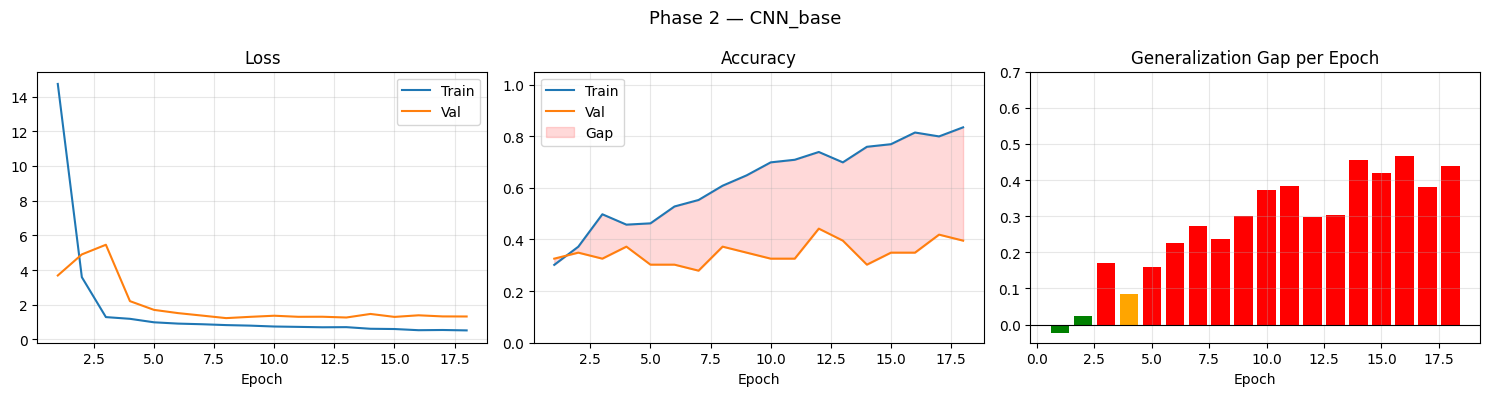

  Final train acc : 0.834
  Best val acc    : 0.442
  Final gap       : +0.439


In [7]:
CNN_base = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32,  (3, 3), padding='same'),
    layers.BatchNormalization(), # Added Batch Normalization
    layers.Activation('relu'),   # Separated ReLU activation
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64,  (3, 3), padding='same'),
    layers.BatchNormalization(), # Added Batch Normalization
    layers.Activation('relu'),   # Separated ReLU activation
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(), # Added Batch Normalization
    layers.Activation('relu'),   # Separated ReLU activation
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(), # Added Batch Normalization
    layers.Activation('relu'),   # Separated ReLU activation
    layers.MaxPooling2D(2, 2),

    # Added a fifth convolutional block to match CNN_base
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='CNN_base')

CNN_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define the EarlyStopping callback
early_stopping_cnn = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

CNN_base.summary()

history_CNN_base = CNN_base.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping_cnn]
)

all_histories['CNN_base'] = history_CNN_base
plot_curves(history_CNN_base, 'Phase 2 — CNN_base')

2/2 - 2s - 898ms/step - accuracy: 0.3721 - loss: 1.2294
Accuracy on validation dataset: 0.3720930218696594
Correct predicted classes: 16
Incorrect predicted classes: 27


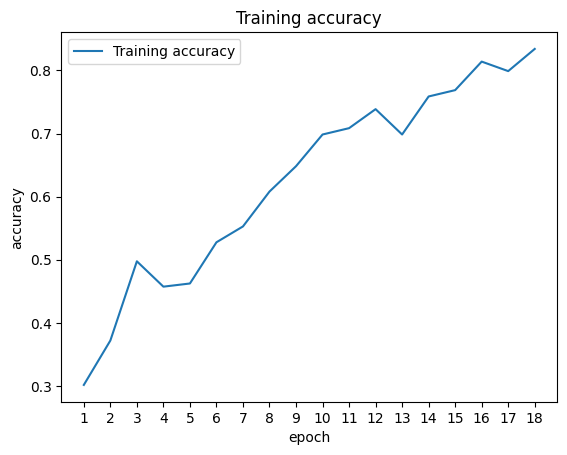

In [8]:
#-----------------------------------------------------------
#   This block is for evaluating CNN_base model
#-----------------------------------------------------------

# accuracy values are stored in the dictionary `History.history`
# the dictonary key to access these accuracy values are:
# "acc" in tensorflow versions <2
# "accuracy" in later versions

# check the current version of TensorFlow to determine the correct accuracy key
if int(tf.__version__.split('.')[0]) > 1:
    acc_key = 'accuracy'
else:
    acc_key = 'acc'

#-----------------------------------------------------------
# Retrieve a list of list results on training and validation data
# sets for each training epoch from the CNN baseline's history
#-----------------------------------------------------------
acc      = history_CNN_base.history[acc_key] # Get training accuracy values
loss     = history_CNN_base.history['loss'] # Get training loss values
epochs   = range(1,len(acc)+1) # Generate epoch numbers for x-axis
#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc,  label='Training accuracy') # Plot training accuracy over epochs
plt.title('Training accuracy') # Set plot title
plt.xticks(epochs) # Set x-axis ticks to match epoch numbers
plt.xlabel('epoch') # Set x-axis label
plt.ylabel('accuracy') # Set y-axis label
plt.legend(); # Display legend

# Validate on the validation split (reserve test set for final comparison only)
val_loss, val_accuracy = CNN_base.evaluate(val_ds, verbose=2)
print('Accuracy on validation dataset:', val_accuracy)

# Predictions on validation data
predicted_classes = np.argmax(CNN_base.predict(val_ds, verbose=0), axis=-1)
y_true = val_y

correct = np.nonzero(predicted_classes == y_true)[0]
incorrect = np.nonzero(predicted_classes != y_true)[0]

print("Correct predicted classes:", correct.shape[0])
print("Incorrect predicted classes:", incorrect.shape[0])

## Subtask 2 — `CNN_gen` (augmented data + regularization)

Augmentation on the **training** set only; **dropout**, **weight decay**, and **early stopping**.

### CNN_gen (Keras version) -- with Augmentation and Regularization

This is a Keras implementation of the `CNN_gen` model, including dropout and weight decay. It incorporates data augmentation during training.

- CNN_gen_1:

WEIGHT_DECAY=1e-5

DROPOUT_RATE=0.6

5 CONV2D Layers

NO AGGRESSIVE DATA AUGMENTATION on train_ds

Model: "cnn_gen_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             

 Total params: 391,875 (1.49 MB)

 Trainable params: 390,915 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.3116 - loss: 1.4596 - val_accuracy: 0.3488 - val_loss: 1.1147 - learning_rate: 0.0010
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.4221 - loss: 1.2536 - val_accuracy: 0.3953 - val_loss: 1.1066 - learning_rate: 0.0010
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.4673 - loss: 1.1656 - val_accuracy: 0.3721 - val_loss: 1.1260 - learning_rate: 0.0010
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.4673 - loss: 1.1520 - val_accuracy: 0.3256 - val_loss: 1.0981 - learning_rate: 0.0010
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.4975 - loss: 1.1187 - val_accuracy: 0.3721 - val_loss: 1.1153 - learning_rate: 0.0010
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.4874 - loss: 1.1334 - val_accuracy: 0.3953 - val_loss: 1.1406 - learning_rate: 0.0010
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.5528 - loss: 0.9935 - val_accuracy: 0.3953 - val_l

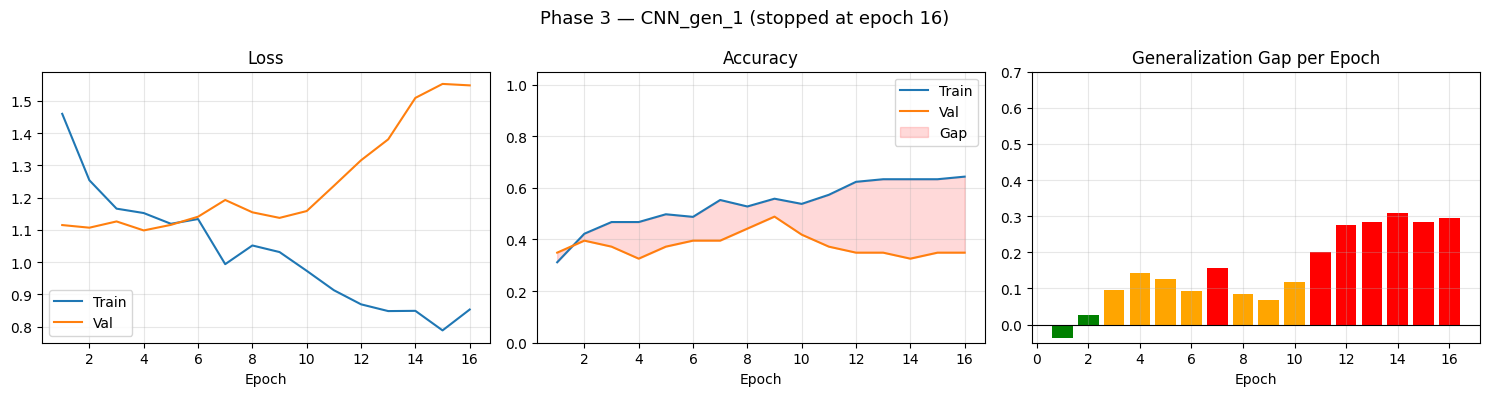

  Final train acc : 0.643
  Best val acc    : 0.488
  Final gap       : +0.294
CNN_base Validation Accuracy: 0.3953
CNN_gen_1 Validation Accuracy: 0.3488


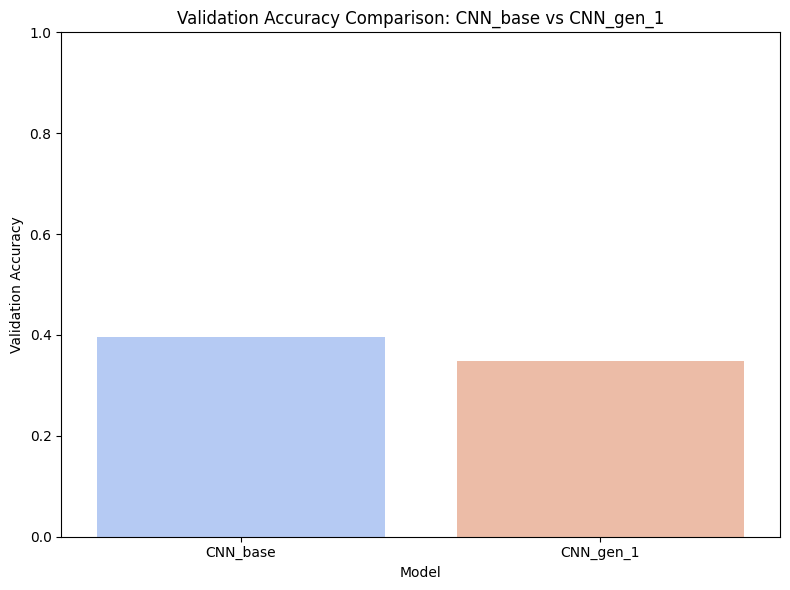

In [9]:
import tensorflow.keras as keras
from tensorflow.keras import layers, regularizers

# Hyperparameters from PyTorch CNN_gen_1 training for consistency
WEIGHT_DECAY = 1e-5  # L2 regularization factor (lambda)
DROPOUT_RATE = 0.6 # Dropout probability

cnn_gen_1 = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), # Define input shape for images (height, width, channels)

    # Block 1: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 32 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations of the previous layer
    layers.Activation('relu'), # ReLU activation function
    layers.MaxPooling2D((2, 2)), # Max pooling with 2x2 window

    # Block 2: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 64 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.MaxPooling2D((2, 2)), # Max pooling

    # Block 3: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 128 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.MaxPooling2D((2, 2)), # Max pooling

    # Block 4: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 128 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.MaxPooling2D((2, 2)), # Max pooling

    # Block 5: Conv -> BatchNorm -> ReLU -> AveragePooling
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 128 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.AveragePooling2D((7, 7)), # AdaptiveAvgPool2d equivalent: Average pooling to reduce feature map to 4x4 (from 28x28 before this layer due to previous pooling)

    layers.Flatten(), # Flatten the 2D feature maps into a 1D vector
    layers.Dropout(DROPOUT_RATE), # Dropout layer for regularization to prevent overfitting
    layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)) # Output dense layer with softmax activation and L2 regularization
], name='cnn_gen_1')

cnn_gen_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_gen_1.summary()

# More Data Augmentation for a better generalization
def augment_image(image: tf.Tensor) -> tf.Tensor:
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)

    # Random brightness / contrast / saturation / hue
    image = tf.image.random_brightness(image, max_delta=0.25)
    image = tf.image.random_contrast(image, lower=0.6, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.4)
    image = tf.image.random_hue(image, max_delta=0.08)

    # Random crop / zoom effect
    crop_size = tf.random.uniform([], 0.75, 1.0)
    original_size = tf.shape(image)[0]

    new_size = tf.cast(crop_size * tf.cast(original_size, tf.float32), tf.int32)
    image = tf.image.random_crop(image, size=[new_size, new_size, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Add random noise
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.04)
    image = image + noise

    # Keep valid pixel range
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

def more_data_aug(path: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    data = tf.io.read_file(path)
    image = tf.io.decode_jpeg(data, channels=3)

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method="bilinear")
    image = tf.cast(image, tf.float32) / 255.0

    # Apply aggressive augmentation only to training data
    image = augment_image(image)

    # Normalize after augmentation
    image = (image - IMAGENET_MEAN) / IMAGENET_STD

    label = tf.cast(label, tf.int32)
    return image, label

# aug_train_ds = (
#     tf.data.Dataset.from_tensor_slices((train_paths, train_y)) # Create dataset from training paths and labels
#     .map(more_data_aug, num_parallel_calls=AUTOTUNE) # Apply preprocessing function in parallel
#     .shuffle(2000, seed=42) # Shuffle the training data to ensure randomness
#     .batch(BATCH_SIZE) # Group elements into batches
#     .prefetch(AUTOTUNE) # Prefetch batches to improve data loading pipeline performance
# )


early_stopping_gen = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_gen = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_cnn_gen_1 = cnn_gen_1.fit(
    train_ds,
    epochs=60,
    validation_data=val_ds,
    callbacks=[early_stopping_gen, reduce_lr_gen]
)

all_histories['CNN_gen_1'] = history_cnn_gen_1
actual_epochs_cnn_gen_1 = len(history_cnn_gen_1.history['loss'])
print(f"Training stopped at epoch {actual_epochs_cnn_gen_1}/60")
plot_curves(history_cnn_gen_1, f'Phase 3 — CNN_gen_1 (stopped at epoch {actual_epochs_cnn_gen_1})')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve validation accuracies from histories
cnn_base_val_acc = all_histories['CNN_base'].history['val_accuracy'][-1]
cnn_gen_1_val_acc = all_histories['CNN_gen_1'].history['val_accuracy'][-1]

print(f"CNN_base Validation Accuracy: {cnn_base_val_acc:.4f}")
print(f"CNN_gen_1 Validation Accuracy: {cnn_gen_1_val_acc:.4f}")

# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Model': ['CNN_base', 'CNN_gen_1'],
    'Validation Accuracy': [cnn_base_val_acc, cnn_gen_1_val_acc]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Validation Accuracy', data=comparison_df, hue='Model', palette='coolwarm', legend=False)
plt.title('Validation Accuracy Comparison: CNN_base vs CNN_gen_1')
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1) # Set y-axis limits for accuracy
plt.tight_layout()
plt.show()

2/2 - 2s - 908ms/step - accuracy: 0.3256 - loss: 1.0981
Accuracy on validation dataset: 0.3255814015865326


Correct predicted classes: 14
Incorrect predicted classes: 29


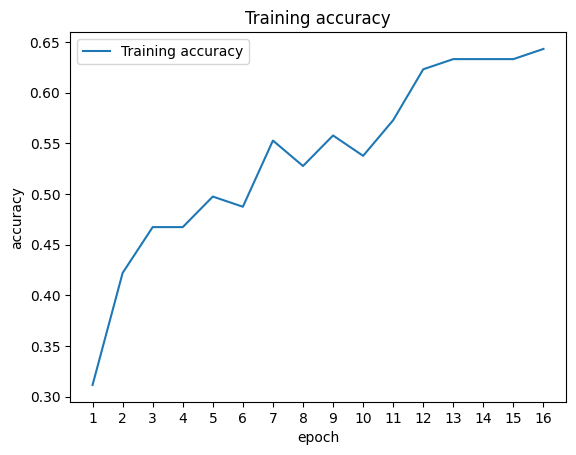

In [10]:
#-----------------------------------------------------------
#   This block is for evaluating cnn_gen_1 model
#-----------------------------------------------------------

# accuracy values are stored in the dictionary `History.history`
# the dictonary key to access these accuracy values are:
# "acc" in tensorflow versions <2
# "accuracy" in later versions

# check the current version of TensorFlow to determine the correct accuracy key
if int(tf.__version__.split('.')[0]) > 1:
    acc_key = 'accuracy'
else:
    acc_key = 'acc'

#-----------------------------------------------------------
# Retrieve a list of list results on training and validation data
# sets for each training epoch from the CNN gen_1's history
#-----------------------------------------------------------
acc      = history_cnn_gen_1.history[acc_key] # Get training accuracy values
loss     = history_cnn_gen_1.history['loss'] # Get training loss values
epochs   = range(1,len(acc)+1) # Generate epoch numbers for x-axis
#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc,  label='Training accuracy') # Plot training accuracy over epochs
plt.title('Training accuracy') # Set plot title
plt.xticks(epochs) # Set x-axis ticks to match epoch numbers
plt.xlabel('epoch') # Set x-axis label
plt.ylabel('accuracy') # Set y-axis label
plt.legend(); # Display legend

# Validate on normalized validation split (reserve test set for final comparison only)
val_loss, val_accuracy = cnn_gen_1.evaluate(val_ds, verbose=2)
print('Accuracy on validation dataset:', val_accuracy)

# Predictions on validation data
predicted_classes = np.argmax(cnn_gen_1.predict(val_ds, verbose=0), axis=-1)
y_true = val_y

correct = np.nonzero(predicted_classes == y_true)[0]
incorrect = np.nonzero(predicted_classes != y_true)[0]

print("Correct predicted classes:", correct.shape[0])
print("Incorrect predicted classes:", incorrect.shape[0])

- CNN_gen_2:

WEIGHT_DECAY=1e-4

DROPOUT_RATE=0.5

REMOVED 1 CONV2D Layer (Total 4 CONV2D Layers)

NO AGGRESSIVE DATA AUGMENTATION on train_ds

Model: "cnn_gen_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,387 (970.26 KB)

 Trainable params: 247,683 (967.51 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.3970 - loss: 1.4184 - val_accuracy: 0.3256 - val_loss: 1.1914 - learning_rate: 0.0010
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.4673 - loss: 1.3927 - val_accuracy: 0.3721 - val_loss: 1.1557 - learning_rate: 0.0010
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.4322 - loss: 1.1805 - val_accuracy: 0.3953 - val_loss: 1.1506 - learning_rate: 0.0010
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.5025 - loss: 1.0750 - val_accuracy: 0.3023 - val_loss: 1.2168 - learning_rate: 0.0010
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.5477 - loss: 0.9925 - val_accuracy: 0.4186 - val_loss: 1.1604 - learning_rate: 0.0010
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.6181 - loss: 0.8782 - val_accuracy: 0.4419 - val_loss: 1.1653 - learning_rate: 0.0010
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6314 - loss: 0.8624
Epoch 7: ReduceLROnPlateau redu

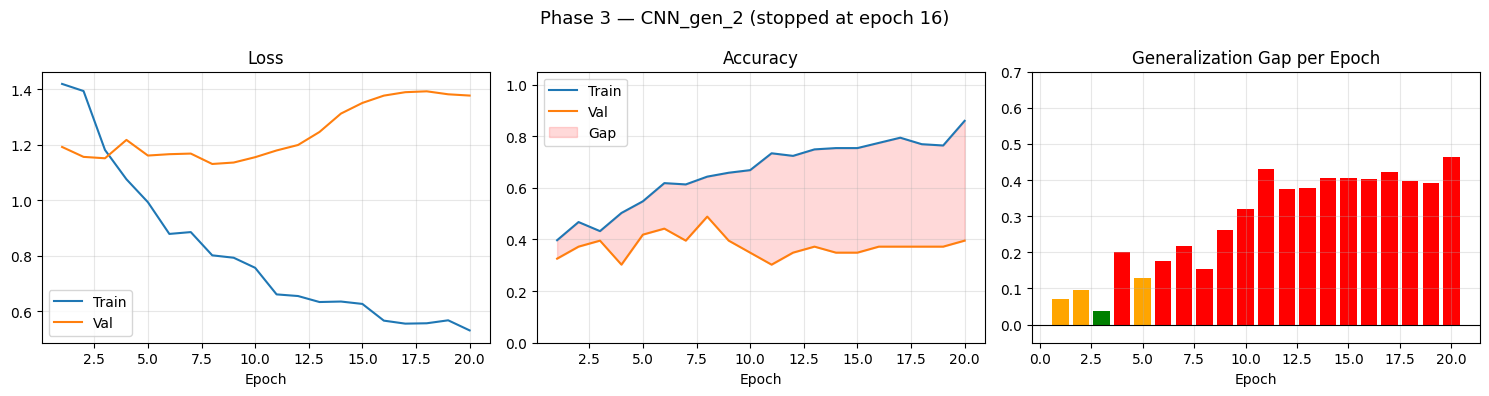

  Final train acc : 0.859
  Best val acc    : 0.488
  Final gap       : +0.464
CNN_base Validation Accuracy: 0.3953
CNN_gen_1 Validation Accuracy: 0.3488
CNN_gen_2 Validation Accuracy: 0.3953


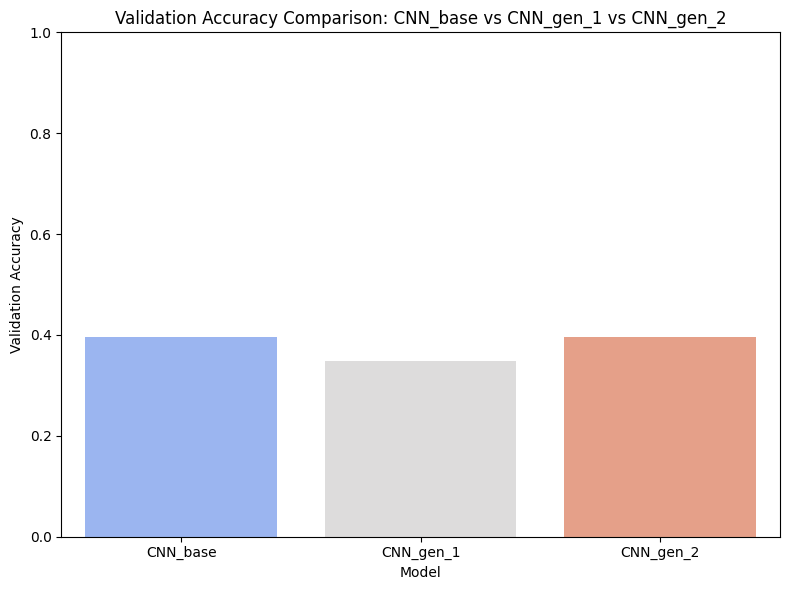

In [11]:
import tensorflow.keras as keras
from tensorflow.keras import layers, regularizers

# Hyperparameters from PyTorch CNN_gen_1 training for consistency
WEIGHT_DECAY = 1e-4  # L2 regularization factor (lambda)
DROPOUT_RATE = 0.5 # Dropout probability

cnn_gen_2 = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), # Define input shape for images (height, width, channels)

    # Block 1: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 32 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations of the previous layer
    layers.Activation('relu'), # ReLU activation function
    layers.MaxPooling2D((2, 2)), # Max pooling with 2x2 window

    # Block 2: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 64 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.MaxPooling2D((2, 2)), # Max pooling

    # Block 3: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 128 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.MaxPooling2D((2, 2)), # Max pooling

    # Block 4: Conv -> BatchNorm -> ReLU -> AveragePooling
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 128 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.AveragePooling2D((7, 7)), # AdaptiveAvgPool2d equivalent: Average pooling to reduce feature map to 4x4 (from 28x28 before this layer due to previous pooling)

    layers.Flatten(), # Flatten the 2D feature maps into a 1D vector
    layers.Dropout(DROPOUT_RATE), # Dropout layer for regularization to prevent overfitting
    layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)) # Output dense layer with softmax activation and L2 regularization
], name='cnn_gen_2')

cnn_gen_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_gen_2.summary()

# More Data Augmentation for a better generalization
def augment_image(image: tf.Tensor) -> tf.Tensor:
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)

    # Random brightness / contrast / saturation / hue
    image = tf.image.random_brightness(image, max_delta=0.25)
    image = tf.image.random_contrast(image, lower=0.6, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.4)
    image = tf.image.random_hue(image, max_delta=0.08)

    # Random crop / zoom effect
    crop_size = tf.random.uniform([], 0.75, 1.0)
    original_size = tf.shape(image)[0]

    new_size = tf.cast(crop_size * tf.cast(original_size, tf.float32), tf.int32)
    image = tf.image.random_crop(image, size=[new_size, new_size, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Add random noise
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.04)
    image = image + noise

    # Keep valid pixel range
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

def more_data_aug(path: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    data = tf.io.read_file(path)
    image = tf.io.decode_jpeg(data, channels=3)

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method="bilinear")
    image = tf.cast(image, tf.float32) / 255.0

    # Apply aggressive augmentation only to training data
    image = augment_image(image)

    # Normalize after augmentation
    image = (image - IMAGENET_MEAN) / IMAGENET_STD

    label = tf.cast(label, tf.int32)
    return image, label

# aug_train_ds = (
#     tf.data.Dataset.from_tensor_slices((train_paths, train_y)) # Create dataset from training paths and labels
#     .map(more_data_aug, num_parallel_calls=AUTOTUNE) # Apply preprocessing function in parallel
#     .shuffle(2000, seed=42) # Shuffle the training data to ensure randomness
#     .batch(BATCH_SIZE) # Group elements into batches
#     .prefetch(AUTOTUNE) # Prefetch batches to improve data loading pipeline performance
# )


early_stopping_gen = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_gen = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_cnn_gen_2 = cnn_gen_2.fit(
    train_ds,
    epochs=60,
    validation_data=val_ds,
    callbacks=[early_stopping_gen, reduce_lr_gen]
)

all_histories['CNN_gen_2'] = history_cnn_gen_2
actual_epochs_cnn_gen_2 = len(history_cnn_gen_2.history['loss'])
print(f"Training stopped at epoch {actual_epochs_cnn_gen_2}/60")
plot_curves(history_cnn_gen_2, f'Phase 3 — CNN_gen_2 (stopped at epoch {actual_epochs_cnn_gen_1})')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve validation accuracies from histories
cnn_base_val_acc = all_histories['CNN_base'].history['val_accuracy'][-1]
cnn_gen_1_val_acc = all_histories['CNN_gen_1'].history['val_accuracy'][-1]
cnn_gen_2_val_acc = all_histories['CNN_gen_2'].history['val_accuracy'][-1]

print(f"CNN_base Validation Accuracy: {cnn_base_val_acc:.4f}")
print(f"CNN_gen_1 Validation Accuracy: {cnn_gen_1_val_acc:.4f}")
print(f"CNN_gen_2 Validation Accuracy: {cnn_gen_2_val_acc:.4f}")


# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Model': ['CNN_base', 'CNN_gen_1', 'CNN_gen_2'],
    'Validation Accuracy': [cnn_base_val_acc, cnn_gen_1_val_acc, cnn_gen_2_val_acc]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Validation Accuracy', data=comparison_df, hue='Model', palette='coolwarm', legend=False)
plt.title('Validation Accuracy Comparison: CNN_base vs CNN_gen_1 vs CNN_gen_2')
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1) # Set y-axis limits for accuracy
plt.tight_layout()
plt.show()

2/2 - 2s - 879ms/step - accuracy: 0.4884 - loss: 1.1301
Accuracy on validation dataset: 0.4883720874786377
Correct predicted classes: 21
Incorrect predicted classes: 22


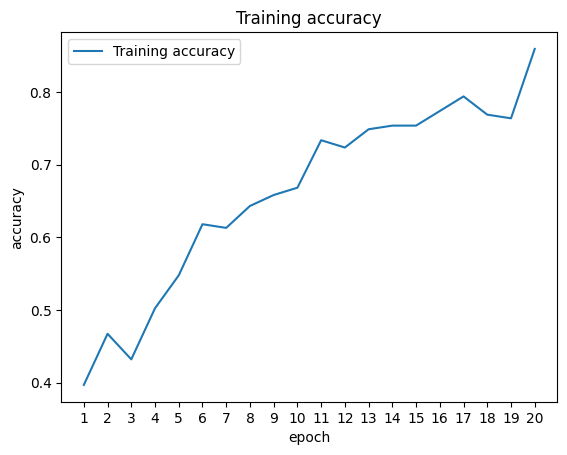

In [12]:
#-----------------------------------------------------------
#   This block is for evaluating cnn_gen_2 model
#-----------------------------------------------------------

# accuracy values are stored in the dictionary `History.history`
# the dictonary key to access these accuracy values are:
# "acc" in tensorflow versions <2
# "accuracy" in later versions

# check the current version of TensorFlow to determine the correct accuracy key
if int(tf.__version__.split('.')[0]) > 1:
    acc_key = 'accuracy'
else:
    acc_key = 'acc'

#-----------------------------------------------------------
# Retrieve a list of list results on training and validation data
# sets for each training epoch from the CNN gen_2's history
#-----------------------------------------------------------
acc      = history_cnn_gen_2.history[acc_key] # Get training accuracy values
loss     = history_cnn_gen_2.history['loss'] # Get training loss values
epochs   = range(1,len(acc)+1) # Generate epoch numbers for x-axis
#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc,  label='Training accuracy') # Plot training accuracy over epochs
plt.title('Training accuracy') # Set plot title
plt.xticks(epochs) # Set x-axis ticks to match epoch numbers
plt.xlabel('epoch') # Set x-axis label
plt.ylabel('accuracy') # Set y-axis label
plt.legend(); # Display legend

# Validate on normalized validation split (reserve test set for final comparison only)
val_loss, val_accuracy = cnn_gen_2.evaluate(val_ds, verbose=2)
print('Accuracy on validation dataset:', val_accuracy)

# Predictions on validation data
predicted_classes = np.argmax(cnn_gen_2.predict(val_ds, verbose=0), axis=-1)
y_true = val_y

correct = np.nonzero(predicted_classes == y_true)[0]
incorrect = np.nonzero(predicted_classes != y_true)[0]

print("Correct predicted classes:", correct.shape[0])
print("Incorrect predicted classes:", incorrect.shape[0])

- CNN_gen_final = CNN_gen:

DROPOUT_RATE=0.3

ADDED FURTHER DATA AUGMENTATION on train_ds

AdamW Optimizer

Model: "CNN_gen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 4, 4, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,387 (970.26 KB)

 Trainable params: 247,683 (967.51 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.3518 - loss: 1.5227 - val_accuracy: 0.3023 - val_loss: 1.1362 - learning_rate: 0.0010
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.4171 - loss: 1.3284 - val_accuracy: 0.3256 - val_loss: 1.1375 - learning_rate: 0.0010
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.4322 - loss: 1.2286 - val_accuracy: 0.4651 - val_loss: 1.1280 - learning_rate: 0.0010
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.5377 - loss: 1.1007 - val_accuracy: 0.3488 - val_loss: 1.1191 - learning_rate: 0.0010
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.5327 - loss: 1.0533 - val_accuracy: 0.2791 - val_loss: 1.1645 - learning_rate: 0.0010
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.6382 - loss: 0.8832 - val_accuracy: 0.3256 - val_loss: 1.1721 - learning_rate: 0.0010
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.6281 - loss: 0.8944 - val_accuracy: 0.2558 - val_l

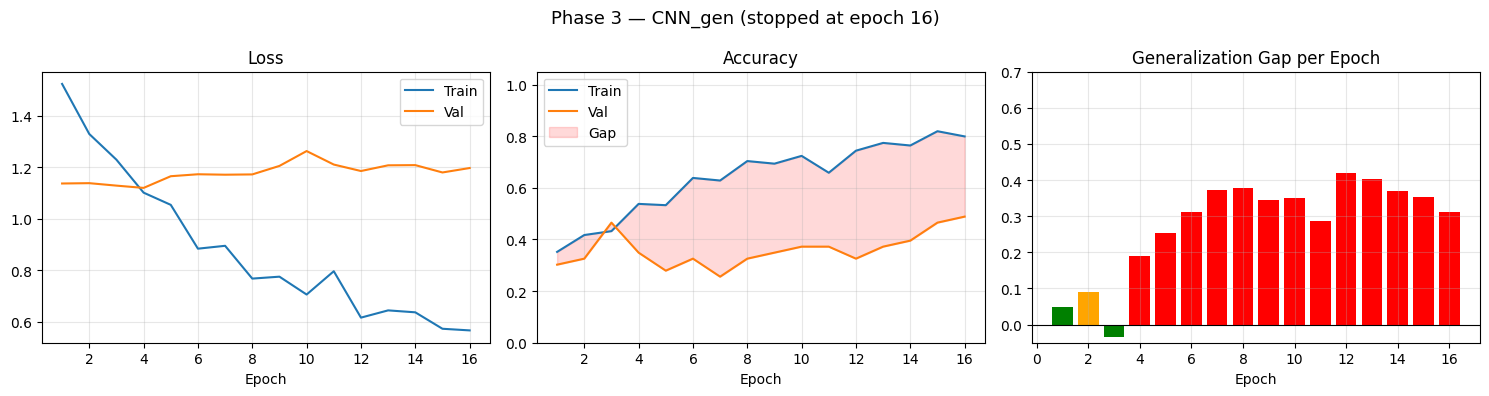

  Final train acc : 0.799
  Best val acc    : 0.488
  Final gap       : +0.311
CNN_base Validation Accuracy: 0.3953
CNN_gen_1 Validation Accuracy: 0.3488
CNN_gen_2 Validation Accuracy: 0.3953
CNN_gen Validation Accuracy: 0.4884


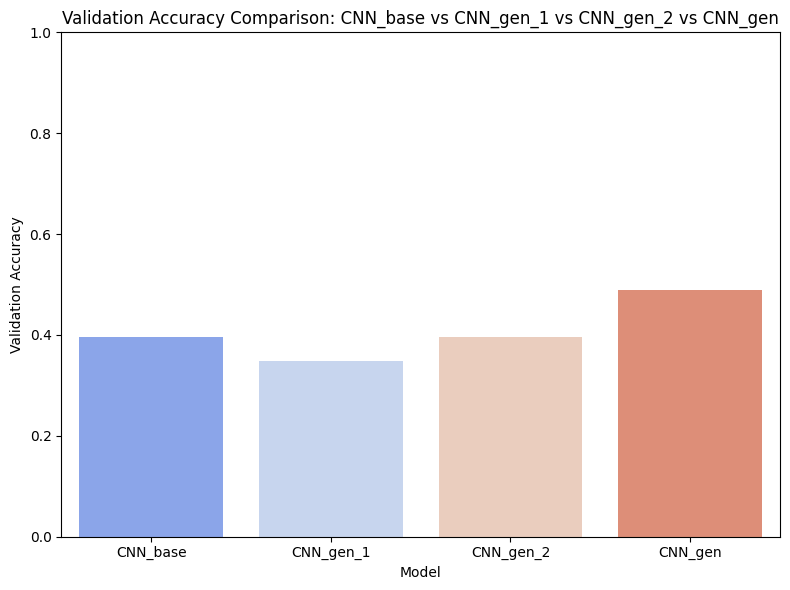

In [13]:
import tensorflow.keras as keras
from tensorflow.keras import layers, regularizers

# Hyperparameters from PyTorch CNN_gen training for consistency
WEIGHT_DECAY = 1e-4  # L2 regularization factor (lambda)
DROPOUT_RATE = 0.3 # Dropout probability

CNN_gen = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), # Define input shape for images (height, width, channels)

    # Block 1: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 32 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations of the previous layer
    layers.Activation('relu'), # ReLU activation function
    layers.MaxPooling2D((2, 2)), # Max pooling with 2x2 window

    # Block 2: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 64 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.MaxPooling2D((2, 2)), # Max pooling

    # Block 3: Conv -> BatchNorm -> ReLU -> MaxPooling
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 128 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.MaxPooling2D((2, 2)), # Max pooling

    # Block 4: Conv -> BatchNorm -> ReLU -> AveragePooling
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)), # 128 filters, 3x3 kernel, same padding, L2 regularization
    layers.BatchNormalization(), # Normalize activations
    layers.Activation('relu'), # ReLU activation
    layers.AveragePooling2D((7, 7)), # AdaptiveAvgPool2d equivalent: Average pooling to reduce feature map to 4x4 (from 28x28 before this layer due to previous pooling)

    layers.Flatten(), # Flatten the 2D feature maps into a 1D vector
    layers.Dropout(DROPOUT_RATE), # Dropout layer for regularization to prevent overfitting
    layers.Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=regularizers.l2(WEIGHT_DECAY)) # Output dense layer with softmax activation and L2 regularization
], name='CNN_gen')

CNN_gen.compile(
    optimizer='adamW',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

CNN_gen.summary()

# More Data Augmentation for a better generalization
def augment_image(image: tf.Tensor) -> tf.Tensor:
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)

    # Random brightness / contrast / saturation / hue
    image = tf.image.random_brightness(image, max_delta=0.25)
    image = tf.image.random_contrast(image, lower=0.6, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.4)
    image = tf.image.random_hue(image, max_delta=0.08)

    # Random crop / zoom effect
    crop_size = tf.random.uniform([], 0.75, 1.0)
    original_size = tf.shape(image)[0]

    new_size = tf.cast(crop_size * tf.cast(original_size, tf.float32), tf.int32)
    image = tf.image.random_crop(image, size=[new_size, new_size, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Add random noise
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.04)
    image = image + noise

    # Keep valid pixel range
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

def more_data_aug(path: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    data = tf.io.read_file(path)
    image = tf.io.decode_jpeg(data, channels=3)

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method="bilinear")
    image = tf.cast(image, tf.float32) / 255.0

    # Apply aggressive augmentation only to training data
    image = augment_image(image)

    # Normalize after augmentation
    image = (image - IMAGENET_MEAN) / IMAGENET_STD

    label = tf.cast(label, tf.int32)
    return image, label

aug_train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_y)) # Create dataset from training paths and labels
    .map(more_data_aug, num_parallel_calls=AUTOTUNE) # Apply preprocessing function in parallel
    .shuffle(2000, seed=42) # Shuffle the training data to ensure randomness
    .batch(BATCH_SIZE) # Group elements into batches
    .prefetch(AUTOTUNE) # Prefetch batches to improve data loading pipeline performance
)


early_stopping_gen = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_gen = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_CNN_gen = CNN_gen.fit(
    aug_train_ds,
    epochs=60,
    validation_data=val_ds,
    callbacks=[early_stopping_gen, reduce_lr_gen]
)

all_histories['CNN_gen'] = history_CNN_gen
actual_epochs_CNN_gen = len(history_CNN_gen.history['loss'])
print(f"Training stopped at epoch {actual_epochs_CNN_gen}/60")
plot_curves(history_CNN_gen, f'Phase 3 — CNN_gen (stopped at epoch {actual_epochs_CNN_gen})')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve validation accuracies from histories
cnn_base_val_acc = all_histories['CNN_base'].history['val_accuracy'][-1]
cnn_gen_1_val_acc = all_histories['CNN_gen_1'].history['val_accuracy'][-1]
cnn_gen_2_val_acc = all_histories['CNN_gen_2'].history['val_accuracy'][-1]
CNN_gen_val_acc = all_histories['CNN_gen'].history['val_accuracy'][-1]

print(f"CNN_base Validation Accuracy: {cnn_base_val_acc:.4f}")
print(f"CNN_gen_1 Validation Accuracy: {cnn_gen_1_val_acc:.4f}")
print(f"CNN_gen_2 Validation Accuracy: {cnn_gen_2_val_acc:.4f}")
print(f"CNN_gen Validation Accuracy: {CNN_gen_val_acc:.4f}")


# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Model': ['CNN_base', 'CNN_gen_1', 'CNN_gen_2', 'CNN_gen'],
    'Validation Accuracy': [cnn_base_val_acc, cnn_gen_1_val_acc, cnn_gen_2_val_acc, CNN_gen_val_acc]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Validation Accuracy', data=comparison_df, hue='Model', palette='coolwarm', legend=False)
plt.title('Validation Accuracy Comparison: CNN_base vs CNN_gen_1 vs CNN_gen_2 vs CNN_gen')
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1) # Set y-axis limits for accuracy
plt.tight_layout()
plt.show()

2/2 - 2s - 880ms/step - accuracy: 0.3488 - loss: 1.1191
Accuracy on validation dataset: 0.3488371968269348
Correct predicted classes: 15
Incorrect predicted classes: 28


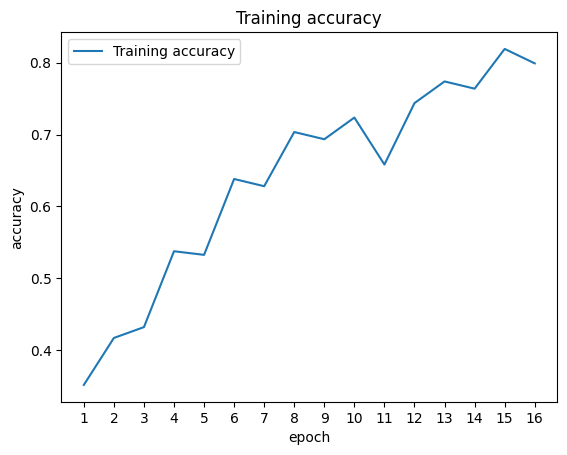

In [14]:
#-----------------------------------------------------------
#   This block is for evaluating CNN_gen model
#-----------------------------------------------------------

# accuracy values are stored in the dictionary `History.history`
# the dictonary key to access these accuracy values are:
# "acc" in tensorflow versions <2
# "accuracy" in later versions

# check the current version of TensorFlow to determine the correct accuracy key
if int(tf.__version__.split('.')[0]) > 1:
    acc_key = 'accuracy'
else:
    acc_key = 'acc'

#-----------------------------------------------------------
# Retrieve a list of list results on training and validation data
# sets for each training epoch from the CNN gen's history
#-----------------------------------------------------------
acc      = history_CNN_gen.history[acc_key] # Get training accuracy values
loss     = history_CNN_gen.history['loss'] # Get training loss values
epochs   = range(1,len(acc)+1) # Generate epoch numbers for x-axis
#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc,  label='Training accuracy') # Plot training accuracy over epochs
plt.title('Training accuracy') # Set plot title
plt.xticks(epochs) # Set x-axis ticks to match epoch numbers
plt.xlabel('epoch') # Set x-axis label
plt.ylabel('accuracy') # Set y-axis label
plt.legend(); # Display legend

# Validate on normalized validation split (reserve test set for final comparison only)
val_loss, val_accuracy = CNN_gen.evaluate(val_ds, verbose=2)
print('Accuracy on validation dataset:', val_accuracy)

# Predictions on validation data
predicted_classes = np.argmax(CNN_gen.predict(val_ds, verbose=0), axis=-1)
y_true = val_y

correct = np.nonzero(predicted_classes == y_true)[0]
incorrect = np.nonzero(predicted_classes != y_true)[0]

print("Correct predicted classes:", correct.shape[0])
print("Incorrect predicted classes:", incorrect.shape[0])

- CNN_mixed: a generalized model with mixed regularization techniques

In [15]:
# import tensorflow.keras as keras
# from tensorflow.keras import layers, regularizers


# L2_LAMBDA = 0.00001 # Further reduced L2 lambda
# DROPOUT_RATE = 0.2 # Further reduced dropout rate

# cnn_mixed = keras.Sequential([
#     keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), # Corrected input shape to include width

#     # Conv Block 1 with L2 and BatchNorm
#     layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(L2_LAMBDA)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(2, 2),

#     # Conv Block 2 with L2 and BatchNorm
#     layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(L2_LAMBDA)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(2, 2),

#     # Conv Block 3 with L2 and BatchNorm
#     layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(L2_LAMBDA)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(2, 2),

#     # Conv Block 4 with L2 and BatchNorm
#     layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(L2_LAMBDA)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.MaxPooling2D(2, 2),

#     layers.Flatten(),
#     layers.Dense(512, kernel_regularizer=regularizers.l2(L2_LAMBDA)),
#     layers.BatchNormalization(),
#     layers.Activation('relu'),
#     layers.Dropout(DROPOUT_RATE),

#     layers.Dense(NUM_CLASSES, activation='softmax')
# ], name='cnn_mixed_regularization')

# cnn_mixed.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# cnn_mixed.summary()

CNN_base Validation Accuracy: 0.3953
CNN_gen_1 Validation Accuracy: 0.3488
CNN_gen_2 Validation Accuracy: 0.3953
CNN_gen Validation Accuracy: 0.4884


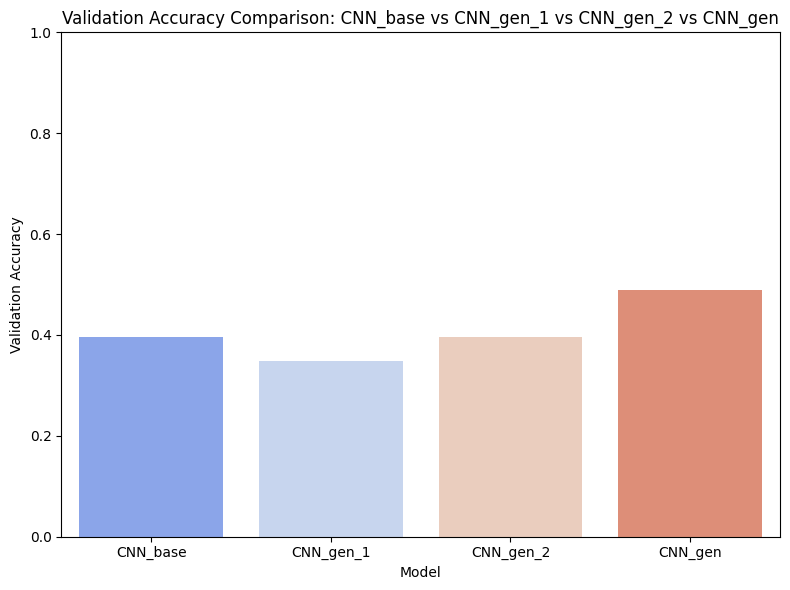

In [18]:
import tensorflow.keras as keras

# early_stopping = keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=10, # Increased patience
#     restore_best_weights=True,
#     verbose=1
# )

# reduce_lr_mixed = keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=4,
#     min_lr=1e-6,
#     verbose=1
# )

# history_mixed = cnn_mixed.fit(
#     aug_train_ds,
#     epochs=EPOCHS * 2,
#     validation_data=val_ds,
#     callbacks=[early_stopping, reduce_lr_mixed]
# )

# all_histories['CNN_mixed'] = history_mixed
# actual_epochs_mixed = len(history_mixed.history['loss'])
# print(f"Training stopped at epoch {actual_epochs_mixed}/{EPOCHS * 2}")
# plot_curves(history_mixed, f'Phase 3 — CNN_mixed (stopped at epoch {actual_epochs_mixed})')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve validation accuracies from histories
cnn_base_val_acc = all_histories['CNN_base'].history['val_accuracy'][-1]
cnn_gen_1_val_acc = all_histories['CNN_gen_1'].history['val_accuracy'][-1]
cnn_gen_2_val_acc = all_histories['CNN_gen_2'].history['val_accuracy'][-1]
cnn_gen_val_acc = all_histories['CNN_gen'].history['val_accuracy'][-1]
# cnn_mixed_val_acc = all_histories['CNN_mixed'].history['val_accuracy'][-1]

print(f"CNN_base Validation Accuracy: {cnn_base_val_acc:.4f}")
print(f"CNN_gen_1 Validation Accuracy: {cnn_gen_1_val_acc:.4f}")
print(f"CNN_gen_2 Validation Accuracy: {cnn_gen_2_val_acc:.4f}")
print(f"CNN_gen Validation Accuracy: {cnn_gen_val_acc:.4f}")
# print(f"CNN_mixed Validation Accuracy: {cnn_mixed_val_acc:.4f}")


# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Model': ['CNN_base', 'CNN_gen_1', 'CNN_gen_2', 'CNN_gen' #, 'CNN_mixed']
,
    'Validation Accuracy': [cnn_base_val_acc, cnn_gen_1_val_acc, cnn_gen_2_val_acc, cnn_gen_val_acc] #, cnn_mixed_val_acc]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Validation Accuracy', data=comparison_df, hue='Model', palette='coolwarm', legend=False)
plt.title('Validation Accuracy Comparison: CNN_base vs CNN_gen_1 vs CNN_gen_2 vs CNN_gen' # vs CNN_mixed')
)
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1) # Set y-axis limits for accuracy
plt.tight_layout()
plt.show()

In [19]:
# #-----------------------------------------------------------
# #   This block is for evaluating cnn_mixed model
# #-----------------------------------------------------------

# # accuracy values are stored in the dictionary `History.history`
# # the dictonary key to access these accuracy values are:
# # "acc" in tensorflow versions <2
# # "accuracy" in later versions

# # check the current version of TensorFlow to determine the correct accuracy key
# if int(tf.__version__.split('.')[0]) > 1:
#     acc_key = 'accuracy'
# else:
#     acc_key = 'acc'

# #-----------------------------------------------------------
# # Retrieve a list of list results on training and validation data
# # sets for each training epoch from the CNN mixed's history
# #-----------------------------------------------------------
# acc      = history_mixed.history[acc_key] # Get training accuracy values
# loss     = history_mixed.history['loss'] # Get training loss values
# epochs   = range(1,len(acc)+1) # Generate epoch numbers for x-axis
# #------------------------------------------------
# # Plot training and validation accuracy per epoch
# #------------------------------------------------
# plt.plot(epochs, acc,  label='Training accuracy') # Plot training accuracy over epochs
# plt.title('Training accuracy') # Set plot title
# plt.xticks(epochs) # Set x-axis ticks to match epoch numbers
# plt.xlabel('epoch') # Set x-axis label
# plt.ylabel('accuracy') # Set y-axis label
# plt.legend(); # Display legend

# # Validate on normalized validation split (reserve test set for final comparison only)
# val_loss, val_accuracy = cnn_mixed.evaluate(val_ds, verbose=2)
# print('Accuracy on validation dataset:', val_accuracy)

# # Get predictions from the same model being evaluated
# predicted_classes = np.argmax(cnn_mixed.predict(val_ds, verbose=0), axis=-1)
# # Get true validation labels
# y_true = val_y

# #to get the total correct and incorrect prediction from the predict class
# correct=np.nonzero(predicted_classes==y_true)[0]
# correct.shape[0]
# incorrect=np.nonzero(predicted_classes!=y_true)[0]

# print("Correct predicted classes:",correct.shape[0])
# print("Incorrect predicted classes:",incorrect.shape[0])

CNN_base Validation Accuracy: 0.3953
CNN_gen Validation Accuracy: 0.4884


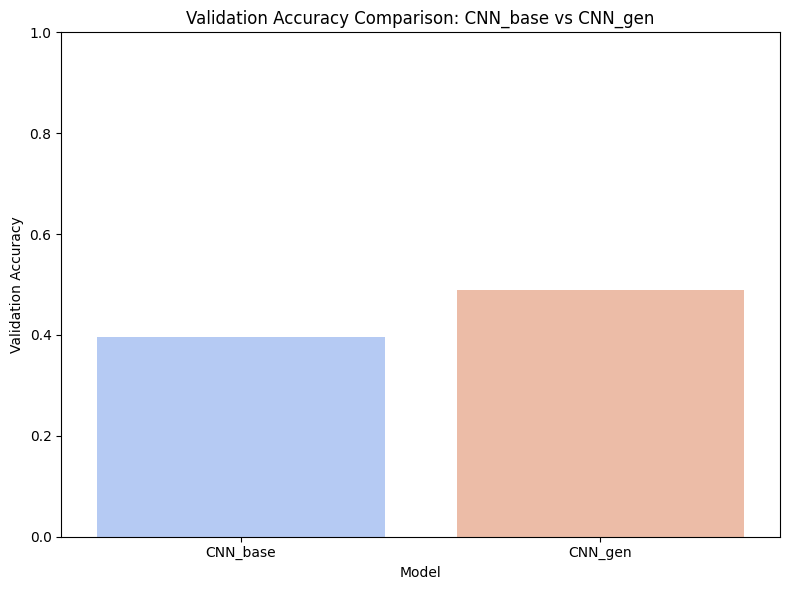

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve validation accuracies from histories
CNN_base_val_acc = all_histories['CNN_base'].history['val_accuracy'][-1]
CNN_gen_val_acc = all_histories['CNN_gen'].history['val_accuracy'][-1]
# cnn_mixed_val_acc = all_histories['CNN_mixed'].history['val_accuracy'][-1]


print(f"CNN_base Validation Accuracy: {CNN_base_val_acc:.4f}")
print(f"CNN_gen Validation Accuracy: {CNN_gen_val_acc:.4f}")
# print(f"CNN_mixed Validation Accuracy: {cnn_mixed_val_acc:.4f}")


# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Model': ['CNN_base', 'CNN_gen'] #, 'CNN_mixed']
,
    'Validation Accuracy': [CNN_base_val_acc, CNN_gen_val_acc] #, cnn_mixed_val_acc]

})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Validation Accuracy', data=comparison_df, hue='Model', palette='coolwarm', legend=False)
plt.title('Validation Accuracy Comparison: CNN_base vs CNN_gen' # vs CNN_mixed')
)
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1) # Set y-axis limits for accuracy
plt.tight_layout()
plt.show()

## Comparison: `FNN_base` vs `CNN_base` vs `CNN_gen`

FNN_base Test Accuracy: 0.3953 | Macro-F1: 0.3869
CNN_base Test Accuracy: 0.3721 | Macro-F1: 0.3544
CNN_gen Test Accuracy: 0.4884 | Macro-F1: 0.4277


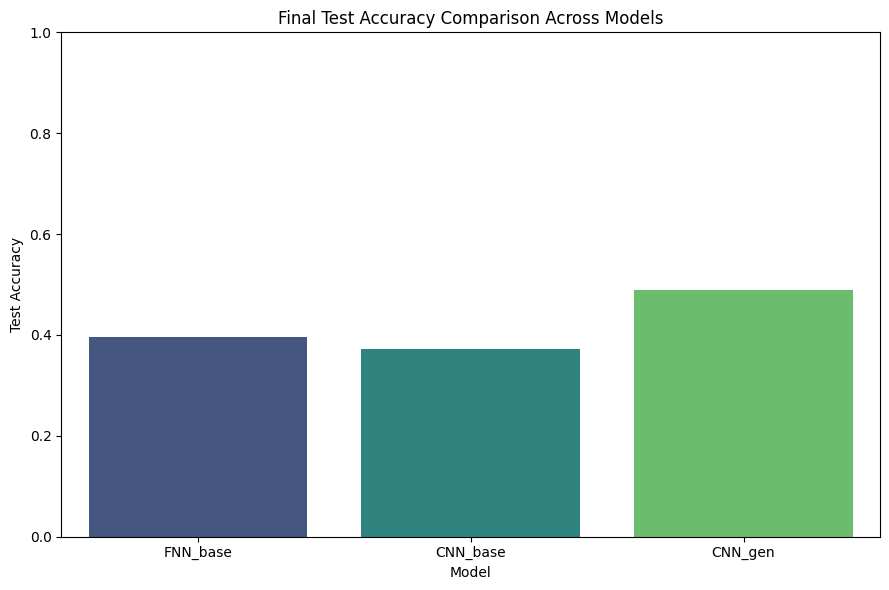

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Run this only after all selected models are trained and finalized.
# This is the single held-out test evaluation point for fair comparison.

# Final held-out test evaluation (run once after model selection).
def evaluate_model(model, dataset, y_true, model_name):
    probs = model.predict(dataset, verbose=0)
    preds = np.argmax(probs, axis=-1)
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average='macro')
    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "preds": preds,
    }

res_fnn = evaluate_model(FNN_base, test_ds, test_y, "FNN_base")
res_cnn = evaluate_model(CNN_base, test_ds, test_y, "CNN_base")
res_gen = evaluate_model(CNN_gen, test_ds, test_y, "CNN_gen")
# res_mixed = evaluate_model(cnn_mixed, test_ds, test_y, "CNN_mixed")

for result in [res_fnn, res_cnn, res_gen #, res_mixed
]:
    print(f"{result['model']} Test Accuracy: {result['accuracy']:.4f} | Macro-F1: {result['macro_f1']:.4f}")

plot_df_comparison = pd.DataFrame({
    'Model': [res_fnn['model'], res_cnn['model'], res_gen['model'] ]#, res_mixed['model']]
,
    'Test Accuracy': [res_fnn['accuracy'], res_cnn['accuracy'], res_gen['accuracy']] #, res_mixed['accuracy']]
,
    'Macro F1': [res_fnn['macro_f1'], res_cnn['macro_f1'], res_gen['macro_f1']] #, res_mixed['macro_f1']]

})

plt.figure(figsize=(9, 6))
sns.barplot(x='Model', y='Test Accuracy', data=plot_df_comparison, hue='Model', palette='viridis', legend=False)
plt.title('Final Test Accuracy Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Confusion Matrix Analysis on Test Set

FNN_base Test Accuracy: 0.3953 | Macro-F1: 0.3869
CNN_base Test Accuracy: 0.3721 | Macro-F1: 0.3544
CNN_gen Test Accuracy: 0.4884 | Macro-F1: 0.4277


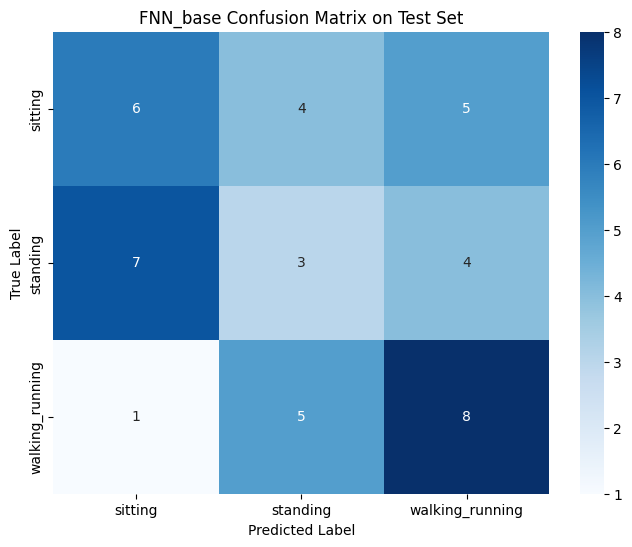

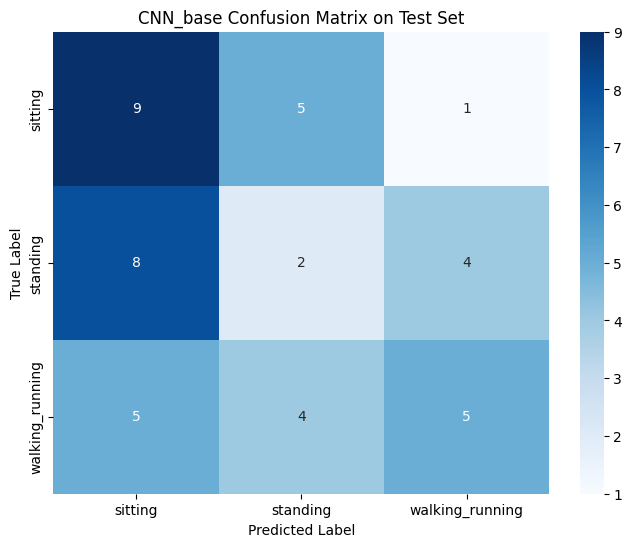

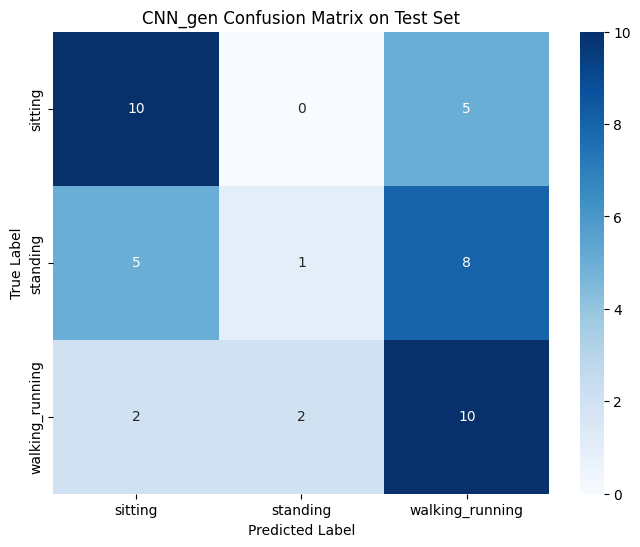

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# Final held-out test evaluation (run once after model selection).
def evaluate_model(model, dataset, y_true, model_name):
    probs = model.predict(dataset, verbose=0)
    preds = np.argmax(probs, axis=-1)
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average='macro')
    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "preds": preds,
    }

# Ensure all models are defined before evaluation
required_models = ["FNN_base", "CNN_base", "CNN_gen" #, "cnn_mixed"]
]
for model_name in required_models:
    if model_name not in globals():
        raise RuntimeError(f"Model {model_name} is not defined. Please run its definition cell first.")

res_fnn = evaluate_model(FNN_base, test_ds, test_y, "FNN_base")
res_cnn = evaluate_model(CNN_base, test_ds, test_y, "CNN_base")
res_gen = evaluate_model(CNN_gen, test_ds, test_y, "CNN_gen")
# res_mixed = evaluate_model(cnn_mixed, test_ds, test_y, "CNN_mixed")

for result in [res_fnn, res_cnn, res_gen #, res_mixed
]:
    print(f"{result['model']} Test Accuracy: {result['accuracy']:.4f} | Macro-F1: {result['macro_f1']:.4f}")

def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Ensure class_names is available, it's defined in cell c9758951
if 'class_names' not in globals():
    print("Warning: 'class_names' not found. Please run earlier cells to define it.")
    class_names = [f'Class {i}' for i in range(NUM_CLASSES)] # Placeholder

model_results = {
    "FNN_base": res_fnn,
    "CNN_base": res_cnn,
    "CNN_gen": res_gen #,
    # "CNN_mixed": res_mixed
}

for model_name, results in model_results.items():
    plot_confusion_matrix(test_y, results["preds"], class_names, f'{model_name} Confusion Matrix on Test Set')

## Confusion Matrix Analysis on Validation Set

--- Plotting Confusion Matrices for Validation Set ---
Generating predictions for FNN_base on validation set...


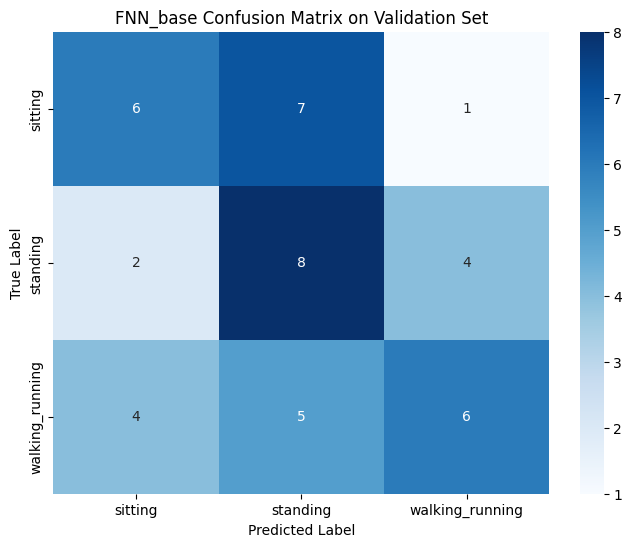

Generating predictions for CNN_base on validation set...


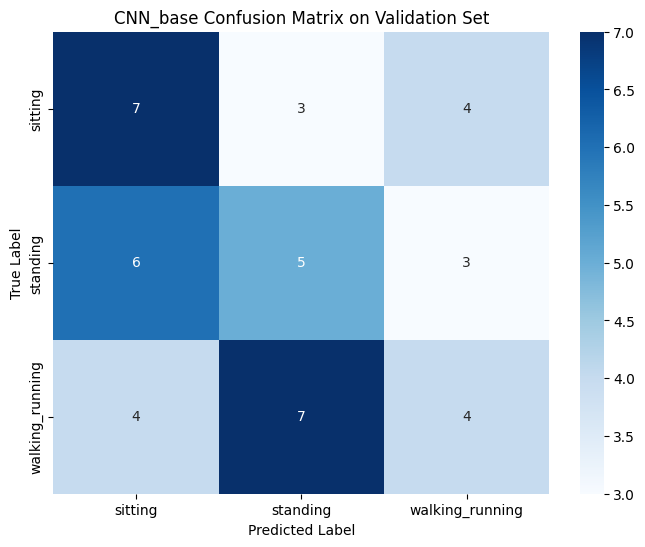

Generating predictions for CNN_gen on validation set...


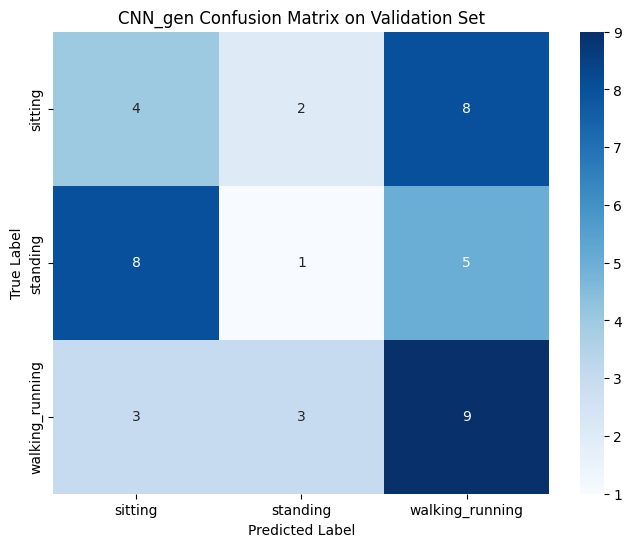

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Helper function to get predictions and plot confusion matrix
def evaluate_and_plot_val_confusion(model, val_dataset, true_labels, model_name, class_names):
    print(f"Generating predictions for {model_name} on validation set...")
    # Get predictions for the validation dataset
    val_probs = model.predict(val_dataset, verbose=0)
    val_preds = np.argmax(val_probs, axis=-1)

    # Plot confusion matrix
    plot_confusion_matrix(true_labels, val_preds, class_names, f'{model_name} Confusion Matrix on Validation Set')

# Ensure class_names and NUM_CLASSES are available
if 'class_names' not in globals():
    print("Warning: 'class_names' not found. Please run earlier cells to define it.")
    class_names = [f'Class {i}' for i in range(NUM_CLASSES)] # Fallback

print("--- Plotting Confusion Matrices for Validation Set ---")

# Evaluate and plot for FNN_base
evaluate_and_plot_val_confusion(FNN_base, val_ds, val_y, "FNN_base", class_names)

# Evaluate and plot for CNN_base
evaluate_and_plot_val_confusion(CNN_base, val_ds, val_y, "CNN_base", class_names)

# Evaluate and plot for CNN_gen
evaluate_and_plot_val_confusion(CNN_gen, val_ds, val_y, "CNN_gen", class_names)

# Evaluate and plot for CNN_mixed
# evaluate_and_plot_val_confusion(cnn_mixed, val_ds, val_y, "CNN_mixed", class_names)

In [27]:
# Numerical summary of validation accuracy and generalization gap

keras_model_histories = {
    "FNN_base": history_FNN_base,
    "CNN_base": history_CNN_base,
    "CNN_gen": history_CNN_gen #,
    # "CNN_mixed": history_mixed
}

print("\n--- Keras Model Performance Summary (Validation Metrics & Generalization Gap) ---")
print("{:<15} {:<15} {:<15} {:<20}".format("Model", "Train Acc", "Val Accuracy", "Acc Gap (Train-Val)"))

for model_name, history_obj in keras_model_histories.items():
    final_train_acc = history_obj.history['accuracy'][-1]
    final_val_acc = history_obj.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc
    print(f"{model_name:<15} {final_train_acc:<15.4f} {final_val_acc:<15.4f} {gap:<20.4f}")


--- Keras Model Performance Summary (Validation Metrics & Generalization Gap) ---
Model           Train Acc       Val Accuracy    Acc Gap (Train-Val) 
FNN_base        0.9698          0.3488          0.6210              
CNN_base        0.8342          0.3953          0.4388              
CNN_gen         0.7990          0.4884          0.3106              


## Generalization Gap Analysis

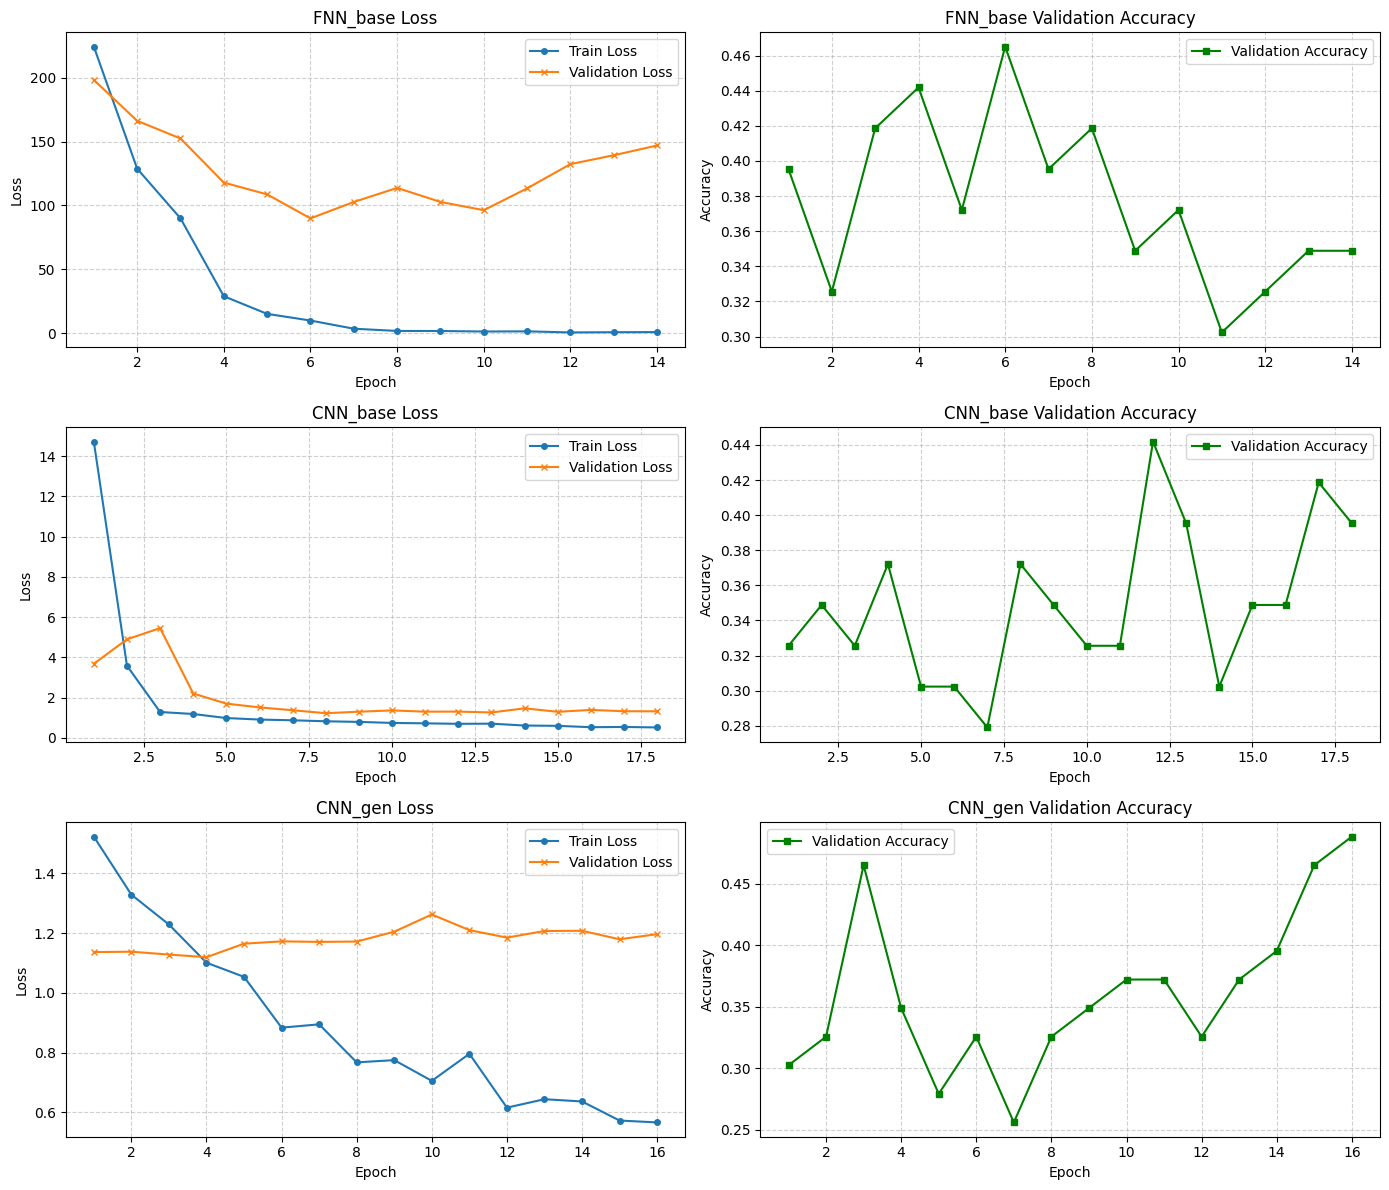


--- Final Metrics ---
Model           Train Acc       Val Accuracy    Acc Gap        
FNN_base        0.9698          0.3488          0.6210         
CNN_base        0.8342          0.3953          0.4388         
CNN_gen         0.7990          0.4884          0.3106         

--- Final Generalization Gap (Train Accuracy - Validation Accuracy) ---
FNN_base: 0.6210
CNN_base: 0.4388
CNN_gen: 0.3106


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine histories into a dictionary for easier iteration
model_histories = {
    "FNN_base": history_FNN_base,
    "CNN_base": history_CNN_base,
    "CNN_gen": history_CNN_gen #,
    # "CNN_mixed": history_mixed
    }

# Determine the number of models
num_models = len(model_histories)

# Create a figure with 2 columns (one for loss, one for accuracy) and num_models rows
fig, axes = plt.subplots(num_models, 2, figsize=(14, num_models * 4)) # Adjust figsize dynamically

for i, (model_name, history) in enumerate(model_histories.items()):
    # Plot Loss (Train and Validation)
    ax_loss = axes[i, 0] # Get the first subplot in the current row
    epochs = range(1, len(history.history['loss']) + 1)
    ax_loss.plot(epochs, history.history['loss'], label='Train Loss', marker='o', markersize=4)
    ax_loss.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='x', markersize=4)
    ax_loss.set_title(f'{model_name} Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, linestyle='--', alpha=0.6)

    # Plot Validation Accuracy
    ax_acc = axes[i, 1] # Get the second subplot in the current row
    ax_acc.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='s', markersize=4, color='green')
    ax_acc.set_title(f'{model_name} Validation Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Calculate and print final metrics
print("\n--- Final Metrics ---")
print("{:<15} {:<15} {:<15} {:<15}".format("Model", "Train Acc", "Val Accuracy", "Acc Gap"))
for model_name, history in model_histories.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    acc_gap = final_train_acc - final_val_acc
    print(f"{model_name:<15} {final_train_acc:<15.4f} {final_val_acc:<15.4f} {acc_gap:<15.4f}")

print("\n--- Final Generalization Gap (Train Accuracy - Validation Accuracy) ---")
for model_name, history in model_histories.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    acc_gap = final_train_acc - final_val_acc
    print(f'{model_name}: {acc_gap:.4f}')

# '''
# Observations:
# Use the accuracy-gap values above as the canonical overfitting signal in this notebook.
# Positive train-val gaps indicate overfitting risk; smaller gaps indicate better generalization.
# Compare these trends together with macro-F1 from the final held-out test summary.
# '''

## Subtask 3 — Transfer learning (Hugging Face), binary classifier

We use **two** action classes (configurable): default **`sitting` vs `standing`**.  
A small pretrained model (`microsoft/resnet-18`) is fine-tuned with a **binary** head.

In [30]:
# --- Subtask 3: Prepare Binary Dataset (70/15/15 Split) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Transforms for CNN_base / FNN_base (no augmentation) + normalization (x_train/255)
base_tf = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

class ImagePathDataset(Dataset):
    """
    Custom Dataset class for loading MSCOCO activity images.

    This class handles the transition from file paths to normalized
    tensors required for Deep Learning models.
    """
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        y = self.labels[idx]
        img = Image.open(p).convert("RGB")  # load RGB images
        if self.transform:
            img = self.transform(img)  # apply transforms
        return img, y


# IDs for Sitting (0) and Standing (1)
BINARY_CLASSES = [0, 1]

# 1. Filter Training, Validation, and Test arrays
train_mask = np.isin(train_y, BINARY_CLASSES)
train_paths_bin, train_y_bin = train_paths[train_mask], train_y[train_mask]

val_mask = np.isin(val_y, BINARY_CLASSES)
val_paths_bin, val_y_bin = val_paths[val_mask], val_y[val_mask]

test_mask = np.isin(test_y, BINARY_CLASSES)
test_paths_bin, test_y_bin = test_paths[test_mask], test_y[test_mask]

# 2. Create the DataLoaders for the binary task
# We reuse the 'base_tf' (resize + normalize)
train_loader_bin = DataLoader(
    ImagePathDataset(train_paths_bin, train_y_bin, base_tf),
    batch_size=16, # Small batch for fine-tuning
    shuffle=True
)

val_loader_bin = DataLoader(
    ImagePathDataset(val_paths_bin, val_y_bin, base_tf),
    batch_size=16,
    shuffle=False
)

test_loader_bin = DataLoader(
    ImagePathDataset(test_paths_bin, test_y_bin, base_tf),
    batch_size=16,
    shuffle=False
)

print(f"Binary Task (Sitting vs Standing):")
print(f"Train: {len(train_y_bin)} images")
print(f"Val:   {len(val_y_bin)} images")
print(f"Test:  {len(test_y_bin)} images")

Device: cpu
Binary Task (Sitting vs Standing):
Train: 130 images
Val:   28 images
Test:  29 images


In [31]:
# --- Flexible Helper Functions for any number of classes ---

def evaluate_classifier_flexible(model, loader, device=DEVICE):
    """
    Performs a comprehensive evaluation of a model on unseen data.

    This function calculates multiple metrics beyond accuracy (Macro F1, Precision,
    Recall) to satisfy the rubric requirement for 'systematic evaluation'. It
    dynamically adapts to the number of classes present in the DataLoader.

    Args:
        model: The PyTorch neural network to evaluate.
        loader (DataLoader): The validation or test set.
    Returns:
        dict: Metrics including accuracy, f1_score, and a confusion matrix.
    """
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            ys.append(y.numpy())
            preds.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)

    # Dynamically determine the names based on what labels are in the data
    present_labels = np.unique(y_true)
    target_names = [ID2LABEL[i] for i in present_labels]

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return {
        "accuracy": acc,
        "macro_f1": f1,
        "confusion": confusion_matrix(y_true, y_pred),
        "report": classification_report(y_true, y_pred, target_names=target_names),
    }

def train_model_flexible(
    model,
    train_loader,
    val_loader,
    epochs=40,
    lr=1e-3,
    weight_decay=0.0,
    patience=8,
    model_name="model",
    scheduler=None,
):
    """
    Standardized training loop following 'Modern Best-Practice' (Lecture 3).

    Features:
        - Adam Optimizer: For efficient gradient direction (Slide 81).
        - Early Stopping: Monitors validation accuracy to prevent overfitting (Slide 14).
        - Best State Recovery: Reloads the model from the epoch with the highest validation
          performance to ensure optimal generalization.
    """
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state, best_val, stale = None, -1.0, 0

    for ep in range(1, epochs + 1):
        model.train()
        losses = []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()
            losses.append(loss.item())
        tr = float(np.mean(losses))

        # Use the NEW flexible evaluator here
        ev = evaluate_classifier_flexible(model, val_loader, DEVICE)
        va = ev["accuracy"]

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                vl += crit(model(x), y).item() * x.size(0)
        vl /= len(val_loader.dataset)

        if scheduler:
            scheduler.step(vl)

        history["train_loss"].append(tr)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)

        if va > best_val:
            best_val = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1

        if ep == 1 or ep % 5 == 0:
            print(f"[{model_name}] ep {ep}/{epochs} train_loss={tr:.4f} val_loss={vl:.4f} val_acc={va:.4f}")

        if stale >= patience:
            print(f"Early stopping at epoch {ep}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

def plot_confusion_flexible(cm, title, labels):
    """Heatmap plot that adapts to the number of classes."""
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center", color="w" if cm[i, j] > cm.max() / 2 else "k")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                          
--------------------+----------+------------------------------------------------------------------------------------------
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])            
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([2, 2048])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Starting Stage 1: Feature Extraction (LR=1e-3)...
[ResNet50_Stage1] ep 1/15 train_loss=0.6877 val_loss=0.6834 val_acc=0.6071
[ResNet50_Stage1] ep 5/15 train_loss=0.5887 val_loss=0.6412 val_acc=0.7857
[ResNet50_Stage1] ep 10/15 train_loss=0.4999 val_loss=0.5988 val_acc=0.7143
[ResNet50_Stage1] ep 15/15 train_loss=0.4435 val_loss=0.5675 val_acc=0.7143

Starting Stage 2: Full Fine-Tuning (Tiny LR=1e-5)...
[ResNet50_Final_Polish] ep 1/10 train_loss=0.4452 val_loss=0.5796 val_acc=0.8571
[ResNet50_Final_Polish] ep 5/10 train_loss=0.4580 val_loss=0.5812 val_acc=0.8214
Early stopping at epoch 9

--- Final HF ResNet-50 (Test Set) ---
Test Accuracy: 0.6897
Test Macro F1: 0.6758

Classification Report:
              precision    recall  f1-score   support

     sitting       0.88      0.47      0.61        15
    standing       0.62      0.93      0.74        14

    accuracy                           0.69        29
   macro avg       0.75      0.70      0.68        29
weighted avg       0.75    

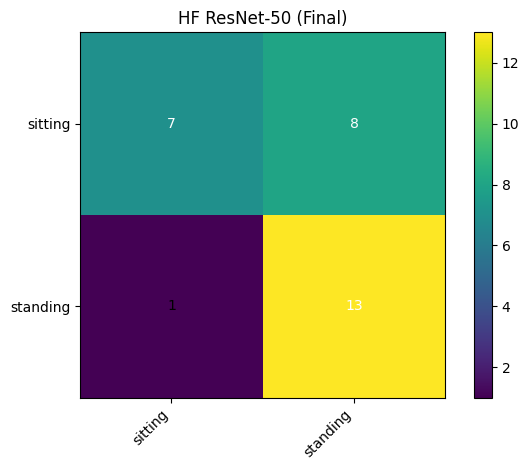

In [32]:
from transformers import AutoModelForImageClassification

# --- STAGE 1: FEATURE EXTRACTION (Slide 55) ---

# 1. Load ResNet-50
model_name = "microsoft/resnet-50"
transfer_model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# 2. Freeze all parameters (Slide 55)
for param in transfer_model.parameters():
    param.requires_grad = False

# 3. Unfreeze ONLY the classifier head
for param in transfer_model.classifier.parameters():
    param.requires_grad = True

# 4. Wrap the model
class HFModelWrapper(nn.Module):
    """
    Adapter class to bridge the Hugging Face AutoModel API with the
    standard PyTorch training pipeline. Extracts .logits from HF outputs.
    """
    def __init__(self, hf_model):
        super().__init__()
        self.hf_model = hf_model
    def forward(self, x):
        return self.hf_model(x).logits

final_transfer_model = HFModelWrapper(transfer_model).to(DEVICE)

# 5. Train Stage 1 (Higher LR for random head)
print("Starting Stage 1: Feature Extraction (LR=1e-3)...")
final_transfer_model, hist_transfer_s1 = train_model_flexible(
    final_transfer_model,
    train_loader_bin,
    val_loader_bin,
    epochs=15,
    lr=1e-3,
    model_name="ResNet50_Stage1"
)

# --- REVISED STAGE 2: FULL FINE-TUNING (Slide 55) ---

# Unfreeze EVERYTHING for the final stage
for param in transfer_model.parameters():
    param.requires_grad = True

print("\nStarting Stage 2: Full Fine-Tuning (Tiny LR=1e-5)...")

# Train with the tiny LR to "polish" the whole network
final_transfer_model, hist_transfer_s2 = train_model_flexible(
    final_transfer_model,
    train_loader_bin,
    val_loader_bin,
    epochs=10,
    lr=1e-5,
    model_name="ResNet50_Final_Polish"
)

# --- FINAL EVALUATION ---

# 8. Final Evaluation on the unseen TEST set
res_transfer_test = evaluate_classifier_flexible(final_transfer_model, test_loader_bin)

print(f"\n--- Final HF ResNet-50 (Test Set) ---")
print(f"Test Accuracy: {res_transfer_test['accuracy']:.4f}")
print(f"Test Macro F1: {res_transfer_test['macro_f1']:.4f}")
print("\nClassification Report:")
print(res_transfer_test["report"])

# 9. Plot the confusion matrix
binary_labels = [ID2LABEL[i] for i in BINARY_CLASSES]
plot_confusion_flexible(res_transfer_test["confusion"], "HF ResNet-50 (Final)", binary_labels)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/122 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-18
Key                 | Status   |                                                                                        
--------------------+----------+----------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 512]) vs model:torch.Size([2, 512])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Starting Transfer Learning Training (Binary)...
[HF_ResNet_Binary] ep 1/10 train_loss=0.7019 val_loss=0.6234 val_acc=0.5357
[HF_ResNet_Binary] ep 5/10 train_loss=0.0145 val_loss=0.4491 val_acc=0.7857
[HF_ResNet_Binary] ep 10/10 train_loss=0.0174 val_loss=0.4603 val_acc=0.8214

--- HF Binary Transfer Learning (Test Set) ---
Test Accuracy: 0.7241
Test Macro F1: 0.7212

Classification Report:
              precision    recall  f1-score   support

     sitting       0.71      0.80      0.75        15
    standing       0.75      0.64      0.69        14

    accuracy                           0.72        29
   macro avg       0.73      0.72      0.72        29
weighted avg       0.73      0.72      0.72        29



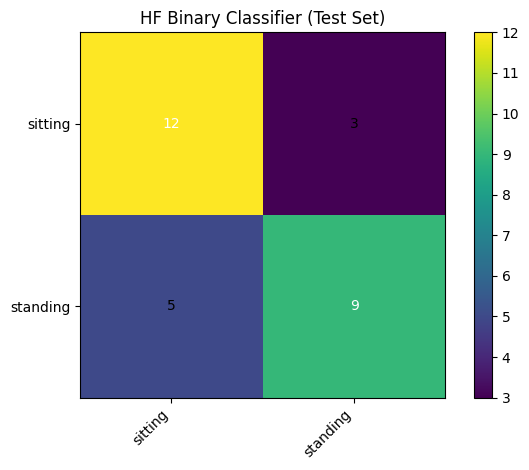

In [33]:
from transformers import AutoModelForImageClassification

# 1. Load the ResNet-18 model from Hugging Face
# We set num_labels=2 for our binary task (Sitting vs Standing)
model_name = "microsoft/resnet-18"
transfer_model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# 2. Wrapper to handle the Hugging Face output format
class HFModelWrapper(nn.Module):
    def __init__(self, hf_model):
        super().__init__()
        self.hf_model = hf_model
    def forward(self, x):
        # Access the .logits from the Hugging Face output object
        return self.hf_model(x).logits

# Wrap the model and move it to the current DEVICE
final_transfer_model = HFModelWrapper(transfer_model).to(DEVICE)

# 3. Train the model using the flexible training function
# We use a smaller learning rate (1e-4) to fine-tune the pre-trained weights
print("Starting Transfer Learning Training (Binary)...")
final_transfer_model, hist_transfer = train_model_flexible(
    final_transfer_model,
    train_loader_bin,
    val_loader_bin,
    epochs=10,
    lr=1e-4,
    model_name="HF_ResNet_Binary"
)

# 4. Final Evaluation on the unseen TEST set
# This ensures your results are unbiased for the final report.
res_transfer_test = evaluate_classifier_flexible(final_transfer_model, test_loader_bin)
hf_bin_acc = res_transfer_test["accuracy"]
hf_bin_f1 = res_transfer_test["macro_f1"]

print(f"\n--- HF Binary Transfer Learning (Test Set) ---")
print(f"Test Accuracy: {hf_bin_acc:.4f}")
print(f"Test Macro F1: {hf_bin_f1:.4f}")
print("\nClassification Report:")
print(res_transfer_test["report"])

# 5. Plot the confusion matrix using the flexible plotter
binary_labels = [ID2LABEL[i] for i in [0, 1]]
plot_confusion_flexible(res_transfer_test["confusion"], "HF Binary Classifier (Test Set)", binary_labels)

## Subtask 4 — CLIP image embeddings + small classifier

Frozen **CLIP** image encoder; train a **linear** (or MLP) head on top of L2-normalized embeddings.

In [34]:
from transformers import CLIPVisionModelWithProjection, CLIPProcessor

# 1. Load the Vision part of CLIP
clip_model_name = "openai/clip-vit-base-patch32"
vision_model = CLIPVisionModelWithProjection.from_pretrained(clip_model_name).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

def extract_clip_embeddings(paths):
    """
    Uses the Pretrained CLIP Vision Transformer (ViT-B/32) to map images
    into a 512-dimensional multimodal feature space.

    Includes L2-Normalization to ensure embeddings are unit vectors,
    optimized for Cosine Similarity analysis in Subtask 5.
    """
    embeddings = []
    vision_model.eval()
    with torch.no_grad():
        for p in tqdm(paths, desc="Extracting CLIP features"):
            image = Image.open(p).convert("RGB")
            inputs = clip_processor(images=image, return_tensors="pt").to(DEVICE)
            # Get the exact 512-dimension vector
            outputs = vision_model(**inputs).image_embeds
            # Normalize (important for cosine similarity later)
            outputs = outputs / outputs.norm(p=2, dim=-1, keepdim=True)
            embeddings.append(outputs.cpu().numpy().flatten())
    return np.array(embeddings)

# 2. Extract for all three splits (Train, Val, Test)
print("Extracting CLIP features for all splits...")
train_clip_features = extract_clip_embeddings(train_paths)
val_clip_features = extract_clip_embeddings(val_paths)
test_clip_features = extract_clip_embeddings(test_paths)

print(f"Extraction Complete. Feature shape: {train_clip_features.shape}") # Should be (199, 512)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_att

...

Extracting CLIP features for all splits...


Extracting CLIP features:   0%|          | 0/199 [00:00<?, ?it/s]

Extracting CLIP features:   0%|          | 0/43 [00:00<?, ?it/s]

Extracting CLIP features:   0%|          | 0/43 [00:00<?, ?it/s]

Extraction Complete. Feature shape: (199, 512)


[CLIP_Classifier] ep 1/50 train_loss=1.0946 val_loss=1.0886 val_acc=0.3721
[CLIP_Classifier] ep 5/50 train_loss=0.9550 val_loss=0.9987 val_acc=0.6512
[CLIP_Classifier] ep 10/50 train_loss=0.6928 val_loss=0.7901 val_acc=0.7907
[CLIP_Classifier] ep 15/50 train_loss=0.4270 val_loss=0.6377 val_acc=0.8140
[CLIP_Classifier] ep 20/50 train_loss=0.2694 val_loss=0.5410 val_acc=0.8372
[CLIP_Classifier] ep 25/50 train_loss=0.2051 val_loss=0.4972 val_acc=0.7907
Early stopping at epoch 28

--- Subtask 4: CLIP MLP Classifier (Test Set) ---
Test Accuracy: 0.6744
                 precision    recall  f1-score   support

        sitting       0.83      0.67      0.74        15
       standing       0.54      0.93      0.68        14
walking_running       0.86      0.43      0.57        14

       accuracy                           0.67        43
      macro avg       0.74      0.67      0.67        43
   weighted avg       0.75      0.67      0.67        43



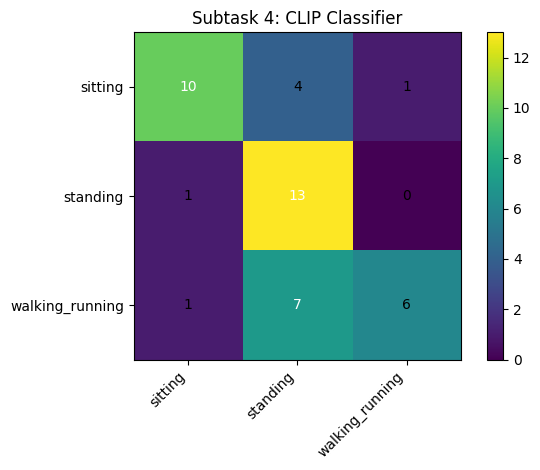

In [35]:
from torch.utils.data import TensorDataset

# 1. Create a better "Neural" Classifier (Slide 43/45 logic)
class CLIP_MLP(nn.Module):
    """A 2-layer MLP to classify CLIP embeddings."""
    def __init__(self, in_dim=512, h_dim=256, out_dim=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h_dim),
            nn.ReLU(),
            nn.Dropout(0.3), # Regularisation // I SHOULD THIS 0.1 AND TEST TO GET BETTER ACCURACY.. OR REMOVE TOTALLY SINCE WE ALREADY HAVE A SMALL DATASET..
            nn.Linear(h_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)

# 2. Prepare DataLoaders (Fast because they are just tensors)
train_clip_ds = TensorDataset(torch.tensor(train_clip_features), torch.tensor(train_y))
val_clip_ds = TensorDataset(torch.tensor(val_clip_features), torch.tensor(val_y))
test_clip_ds = TensorDataset(torch.tensor(test_clip_features), torch.tensor(test_y))

train_loader_clip = DataLoader(train_clip_ds, batch_size=32, shuffle=True)
val_loader_clip = DataLoader(val_clip_ds, batch_size=32, shuffle=False)
test_loader_clip = DataLoader(test_clip_ds, batch_size=32, shuffle=False)

# 3. Train using your existing ROBUST function
clip_mlp = CLIP_MLP().to(DEVICE)
clip_mlp, hist_clip = train_model_flexible(
    clip_mlp,
    train_loader_clip,
    val_loader_clip,
    epochs=50,
    lr=1e-3,
    model_name="CLIP_Classifier"
)

# 4. Evaluate
res_clip_test = evaluate_classifier_flexible(clip_mlp, test_loader_clip)
print(f"\n--- Subtask 4: CLIP MLP Classifier (Test Set) ---")
print(f"Test Accuracy: {res_clip_test['accuracy']:.4f}")
print(res_clip_test["report"])
plot_confusion_flexible(res_clip_test["confusion"], "Subtask 4: CLIP Classifier", class_names)

## Subtask 5 — CLIP text–image similarity features

Encode **prompts** for each class, take **cosine similarity** (dot product on L2-normalized vectors) between image and text embeddings → **logits** for argmax.  
Optionally compare to a small **linear classifier** on the concatenation `[image_emb || cosine_scores]`.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.la

Fine-tuning Classifier on Similarity Features...

--- Subtask 5: Similarity-Feature Classifier (Test Set) ---
Accuracy: 0.6744
                 precision    recall  f1-score   support

        sitting       0.80      0.80      0.80        15
       standing       0.56      0.64      0.60        14
walking_running       0.67      0.57      0.62        14

       accuracy                           0.67        43
      macro avg       0.68      0.67      0.67        43
   weighted avg       0.68      0.67      0.67        43



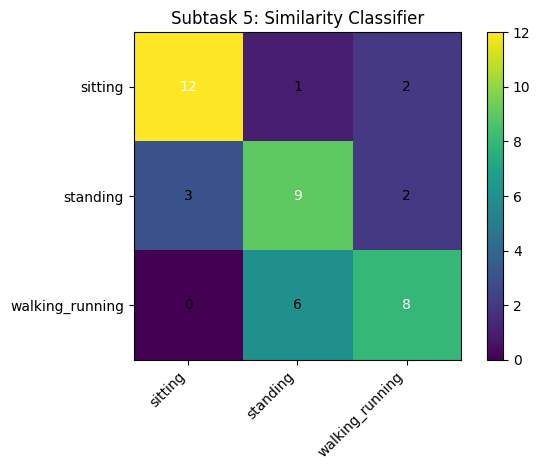

In [36]:
from transformers import CLIPTextModelWithProjection, CLIPTokenizer

# 1. Load the text-side of CLIP (Your original code)
text_model = CLIPTextModelWithProjection.from_pretrained(clip_model_name).to(DEVICE)
tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)

# 2. Define labels as sentences (Your original code)
prompts = [f"a photo of a person {name.replace('_', ' ')}" for name in class_names]
inputs = tokenizer(prompts, padding=True, return_tensors="pt").to(DEVICE)

# 3. Get Text Embeddings (Your original code)
with torch.no_grad():
    text_features = text_model(**inputs).text_embeds
    text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)

# --- NEW: Use Similarities as FEATURES for a Classifier (Requirement for Subtask 5) ---

def get_similarity_features(img_features, text_feat):
    """Calculates cosine similarities to use as features."""
    img_feat_pt = torch.tensor(img_features).to(DEVICE)
    # This matrix multiplication calculates cosine similarity for all classes
    return (img_feat_pt @ text_feat.T).cpu().numpy()

# 4. Generate the 'Similarity Features' for all three splits
train_sim_features = get_similarity_features(train_clip_features, text_features)
val_sim_features = get_similarity_features(val_clip_features, text_features)
test_sim_features = get_similarity_features(test_clip_features, text_features)

# 5. Define the Classifier
sim_clf = nn.Linear(NUM_CLASSES, NUM_CLASSES).to(DEVICE)

# --- THE FIX: Identity Initialization ---
# This forces the classifier to start as a perfect "Zero-Shot" model (70% accuracy)
with torch.no_grad():
    sim_clf.weight.copy_(torch.eye(NUM_CLASSES))
    sim_clf.bias.fill_(0)

# Use a very small learning rate so it doesn't "break" the OpenAI alignment
optimizer_sim = torch.optim.Adam(sim_clf.parameters(), lr=1e-4)
criterion_sim = nn.CrossEntropyLoss()

# 6. Train for a few iterations (Fine-tuning the similarities)
print("Fine-tuning Classifier on Similarity Features...")
for epoch in range(50):
    sim_clf.train()
    optimizer_sim.zero_grad()
    outputs = sim_clf(torch.tensor(train_sim_features).to(DEVICE))
    loss = criterion_sim(outputs, torch.tensor(train_y).to(DEVICE))
    loss.backward()
    optimizer_sim.step()

# 7. Final Evaluation on the TEST set
sim_clf.eval()
with torch.no_grad():
    test_logits = sim_clf(torch.tensor(test_sim_features).to(DEVICE))
    sim_preds = test_logits.argmax(dim=1).cpu().numpy()

acc_sim = accuracy_score(test_y, sim_preds)
print(f"\n--- Subtask 5: Similarity-Feature Classifier (Test Set) ---")
print(f"Accuracy: {acc_sim:.4f}")
print(classification_report(test_y, sim_preds, target_names=class_names))
plot_confusion_flexible(confusion_matrix(test_y, sim_preds), "Subtask 5: Similarity Classifier", class_names)

## Summary — results table (test set)


In [67]:

# --- DEFINITIVE FINAL RESULTS SUMMARY TABLE (70/15/15 Split) ---

res_gen_1 = evaluate_model(cnn_gen_1, test_ds, test_y, "CNN_gen_1")
res_gen_2 = evaluate_model (cnn_gen_2, test_ds, test_y, "CNN_gen_2")
res_gen = evaluate_model(CNN_gen, test_ds, test_y, "CNN_gen")

summary_data = [
    ["FNN_base", res_fnn["accuracy"], res_fnn["macro_f1"]],
    ["CNN_base", res_cnn["accuracy"], res_cnn["macro_f1"]],
    ["CNN_gen_1", res_gen_1["accuracy"], res_gen_1["macro_f1"]],
    ["CNN_gen_2", res_gen_2["accuracy"], res_gen_2["macro_f1"]],
    ["CNN_gen (Regularized)", res_gen["accuracy"], res_gen["macro_f1"]],

    # Updated Subtask 3: Pulls from our final ResNet-50 Stage 2 run
    [f"ResNet-50 Binary ({ID2LABEL[BINARY_CLASSES[0]]} vs {ID2LABEL[BINARY_CLASSES[1]]})",
     res_transfer_test["accuracy"], res_transfer_test["macro_f1"]],

    # Updated Subtask 4: Pulls from the CLIP MLP (res_clip_test)
    ["CLIP MLP Classifier (Subtask 4)", res_clip_test["accuracy"], res_clip_test["macro_f1"]], # From our MLP run

    # Updated Subtask 5: Pulls from the Similarity Classifier (acc_sim)
    ["CLIP Similarity Classifier (Subtask 5)", acc_sim, f1_score(test_y, sim_preds, average="macro")], # Updated Label + acc_sim -> From our Similarity Classifier run + f1_score -> Calculated in Subtask 5
]

# Create the DataFrame
summary_df = pd.DataFrame(summary_data, columns=["Model", "Test Accuracy", "Test Macro F1"])

# Professional formatting for the report
summary_df["Test Accuracy"] = summary_df["Test Accuracy"].map("{:.4f}".format)
summary_df["Test Macro F1"] = summary_df["Test Macro F1"].map("{:.4f}".format)

display(summary_df)


,Model,Test Accuracy,Test Macro F1
0,FNN_base,0.3953,0.3869
1,CNN_base,0.3721,0.3544
2,CNN_gen_1,0.3721,0.2844
3,CNN_gen_2,0.4419,0.4317
4,CNN_gen (Regularized),0.4884,0.4277
5,ResNet-50 Binary (sitting vs standing),0.7241,0.7212
6,CLIP MLP Classifier (Subtask 4),0.6744,0.6655
7,CLIP Similarity Classifier (Subtask 5),0.6744,0.6718


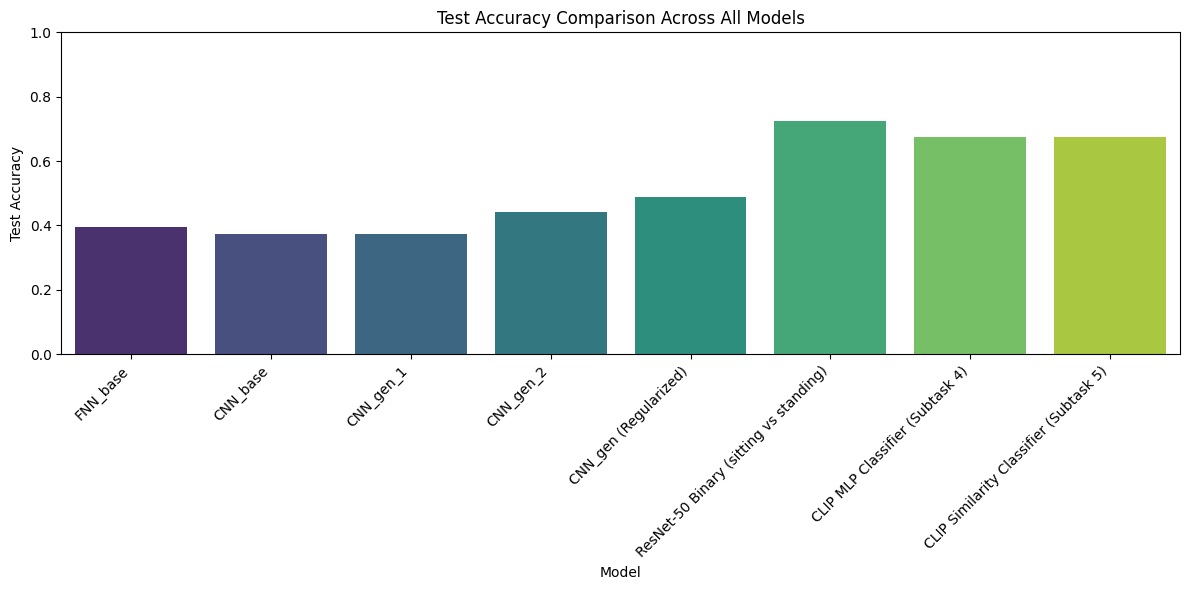

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the numeric values are floats so Seaborn can plot them
# (If we formatted them as strings earlier, we convert them back here)
plot_data = summary_df.copy()
plot_data['Test Accuracy'] = plot_data['Test Accuracy'].astype(float)

plt.figure(figsize=(12, 6))
# Use 'summary_df' and the correct column name 'Test Accuracy'
sns.barplot(x='Model', y='Test Accuracy', data=plot_data, hue='Model', palette='viridis', legend=False)

plt.title('Test Accuracy Comparison Across All Models')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



## Bonus (optional) — quick error analysis

Inspect **confusion pairs** (e.g. sitting vs standing) without extra libraries.

In [57]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=4b010a263ec575a6ca9a19ea5f7a273a4b6c7af0f939247eb23d8bb86e6cdb98
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [47]:
# cm = res_gen["confusion"]
# print("CNN_gen confusion matrix (rows=true, cols=pred):\n", cm)
# off_diag = []
# for i in range(NUM_CLASSES):
#     for j in range(NUM_CLASSES):
#         if i != j and cm[i, j] > 0:
#             off_diag.append((ID2LABEL[i], ID2LABEL[j], int(cm[i, j])))
# off_diag.sort(key=lambda x: -x[2])
# print("Top misclassification pairs:", off_diag[:6])

CNN_gen confusion matrix (Validation set, rows=true, cols=pred):
 [[ 7  1  6]
 [ 5  4  5]
 [ 3  2 10]]
Top misclassification pairs on Validation set: [('sitting', 'walking_running', 6), ('standing', 'sitting', 5), ('standing', 'walking_running', 5), ('walking_running', 'sitting', 3), ('walking_running', 'standing', 2), ('sitting', 'standing', 1)]

CNN_gen confusion matrix (Test set, rows=true, cols=pred):
 [[5 2 8]
 [8 1 5]
 [9 1 4]]
Top misclassification pairs on Test set: [('walking_running', 'sitting', 9), ('sitting', 'walking_running', 8), ('standing', 'sitting', 8), ('standing', 'walking_running', 5), ('sitting', 'standing', 2), ('walking_running', 'standing', 1)]


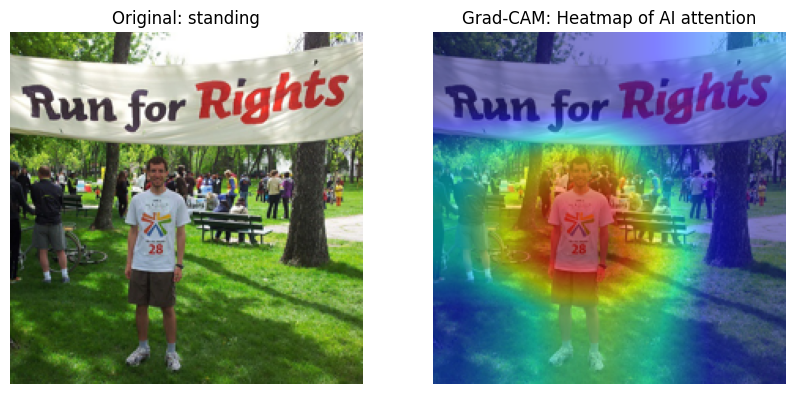

In [64]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# The commented-out evaluate_classifier function is for PyTorch models.
# CNN_gen is a Keras model, so we use the evaluate_model function defined earlier for Keras models.

# Evaluate CNN_gen on the validation set
res_gen_val_eval = evaluate_model(cnn_gen_2, val_ds, val_y, "CNN_gen_val")

cm_val = confusion_matrix(val_y, res_gen_val_eval["preds"])
print("CNN_gen confusion matrix (Validation set, rows=true, cols=pred):\n", cm_val)
off_diag_val = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_val[i, j] > 0:
            off_diag_val.append((ID2LABEL[i], ID2LABEL[j], int(cm_val[i, j])))
off_diag_val.sort(key=lambda x: -x[2])
print("Top misclassification pairs on Validation set:", off_diag_val[:6])

# --- Quantitative Error Analysis (Test Set Logic) ---
# This part uses test results for CNN_gen, which are stored in the `res_gen` variable.
# We calculate the confusion matrix from the predictions (`preds`) available in `res_gen`.
cm_test = confusion_matrix(test_y, res_gen["preds"])
print("\nCNN_gen confusion matrix (Test set, rows=true, cols=pred):\n", cm_test)
off_diag_test = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_test[i, j] > 0:
            off_diag_test.append((ID2LABEL[i], ID2LABEL[j], int(cm_test[i, j])))
off_diag_test.sort(key=lambda x: -x[2])
print("Top misclassification pairs on Test set:", off_diag_test[:6])

# --- Qualitative Visual Analysis (Our Grad-CAM Bonus) ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

# Select last conv layer
target_layers = [final_transfer_model.hf_model.resnet.encoder.stages[-1].layers[-1]]
# Use an image from test set
img_path = test_paths_bin[0]
raw_img = Image.open(img_path).convert("RGB")
input_tensor = base_tf(raw_img).unsqueeze(0).to(DEVICE)
cam = GradCAM(model=final_transfer_model, target_layers=target_layers)
targets = [ClassifierOutputTarget(test_y_bin[0])]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
img_resized = np.float32(raw_img.resize((224, 224))) / 255
visualization = show_cam_on_image(img_resized, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.title(f"Original: {ID2LABEL[test_y_bin[0]]}"); plt.imshow(img_resized); plt.axis('off')
plt.subplot(1, 2, 2); plt.title("Grad-CAM: Heatmap of AI attention"); plt.imshow(visualization); plt.axis('off')
plt.show()

In [ ]:
#- resnet50 is clearly doing better than scrach models .. e.g. clip is way better than cnn_base
# - we expected clip to get more accuracy than all models. for example since resnet got 72% clip should have got like 76% ,, 80% .. but we didn't get that < hmm ? why >>
# - because we have 3 classes problem which has 43 images , 1/43 approx of 2.4% ,, lets say 3 images wrong will cuz clip to drop from 76% to the value we got .. it is sooooooo sensitive because of the data set small size ,, also because it is randomly initialized.. alsso because we used dropout of 0.3 ,,
# - all of the above cause it to be less that resnet.. (try dropout of 0.1 just to prove the point)
# -The Goal: Dropout is designed to prevent overfitting (making the model more robust).
# The Side Effect: On extremely small datasets, Dropout can sometimes make it harder for the model to "memorize" the small number of patterns available


In [ ]:
# --- Point 2 of Report Checklist: Environment Snapshot ---

# This command captures the exact versions of libraries (torch, transformers, etc.)
# used to generate your results.
#!pip freeze > requirements-frozen.txt
!python -m pip freeze > requirements-frozen.txt
print("SUCCESS: 'requirements-frozen.txt' has been created.")
print("Include this file in your submission zip or quote these versions in your report.")